# Code for Ch 1: Basics of Quantum Computing
This Jupyter notebook contains Qiskit code used for Chapter 1 of my tutorial on Quantum Machine Learning (QML), which is based on material from the 2021 Qiskit Summer School on QML and the online Qiskit textbook, and explains how I installed Qiskit.

NB: it's worth noting, that the code here has been created with LLM assistance and by referring to the online Qiskit textbook

In [ ]:
# Boilerplate to run 
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt 
plt.style.use('../intro_to_qml_figure_style.mpltstyle') # This style sheet is in use.
 
import warnings 
warnings.filterwarnings( # Filter out the specific tight_layout warning generated by Jupyter/Matplotlib 3D plots
    "ignore", 
    category=UserWarning, 
    message="This figure includes Axes that are not compatible with tight_layout"
)

from qiskit.visualization import plot_bloch_vector
from qiskit import QuantumCircuit, QuantumRegister
from IPython.display import display
import numpy as np

figure_directory = '../Figures/Ch1_Basics_Figures/'

# Installing Qiskit
This describes how I installed Qiskit, basically following the online Qiskit textbook.

## Pre-requisite: install Python, pip, and open command line.
For this repository, I have installed Qiskit within a virtual environment, and it's version 2.3.0 as of the time of writing this (4/3/26).
For future versions if there's major changes, it's worth checking out the Qiskit textbook.

To install Qiskit, you will need to start getting familiar with the command line and have installed Python.

Personally I installed Python by installing Anaconda, https://www.anaconda.com/docs/getting-started/anaconda/main, though you're free to install it another way such as by installing the basic Python distribution as described here https://wiki.python.org/moin/BeginnersGuide/Download 


First open up your command line app and navigate into the project folder you will work in.

For Mac or Linux this is:
```shell
python3 -m venv .qml_tutorial_env
source .qml_tutorial_env/bin/activate
```
Whereas for Windows PowerShell this will be
```shell
python -m venv .qml_tutorial_env/bin/activate
.qml_tutorial_env\Scripts\Activate.ps1
```

You will need pip to install Qiskit. 
In all likelihood, pip is already installed, and can be checked with commands such as:
```shell
python -m pip --version
```
In case it's not there, how to install pip is described here: https://pip.pypa.io/en/stable/installation/

After this qiskit can be installed as 
```shell
pip install qiskit
```

To run jobs on actual quantum hardware `qiskit-ibm-runtime` is also needed.
```shell
pip install qiskit-ibm-runtime
```

I have also installed the qiskit.visualization module, the qiskit_aer module to model noise, and Jupyter for visualisation within this repository.
```shell
pip install 'qiskit[visualization]'
pip install qiskit_aer
pip install jupyter
```

The version of Python and Qiskit installed can be checked as follows.

In [48]:
import qiskit
import sys
print('Qiskit version:', qiskit.version.get_version_info())
print('Python version:', sys.version)

Qiskit version: 2.3.0
Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]


## Visualisation
The following code blocks contain visualisations used for 

# Basic Bloch sphere representation

In [5]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt 
plt.style.use('intro_to_qml_figure_style.mpltstyle') # This style sheet is in use.
 
import warnings 
warnings.filterwarnings( # Filter out the specific tight_layout warning generated by Jupyter/Matplotlib 3D plots
    "ignore", 
    category=UserWarning, 
    message="This figure includes Axes that are not compatible with tight_layout"
)

from qiskit.visualization import plot_bloch_vector
from IPython.display import display
import numpy as np

figure_directory = 'Figures/Ch1_Basics_Figures/'


'qiskit.visualization.plot_bloch_vector' can be used to plot Bloch vectors as show below, either in the 3D cartesian representation by default (or with coord_type="cartesian"), or the spherical representation chosen by coord_type="spherical"

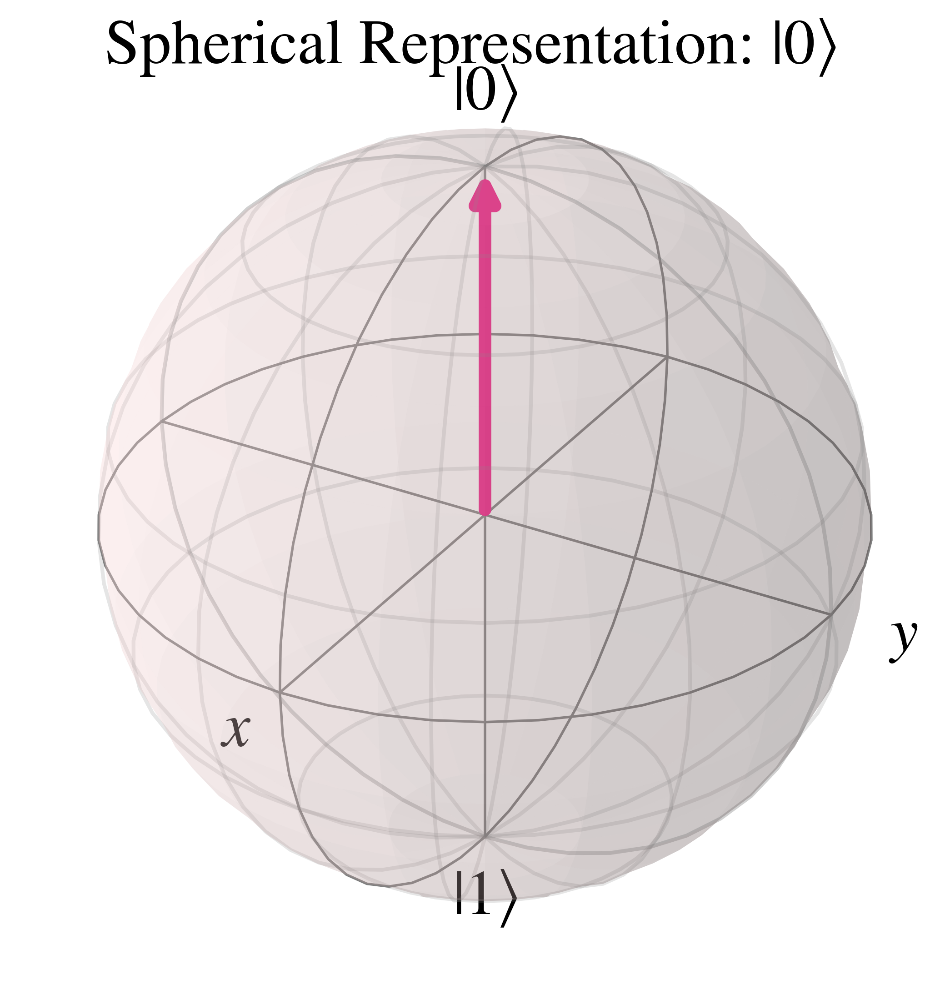

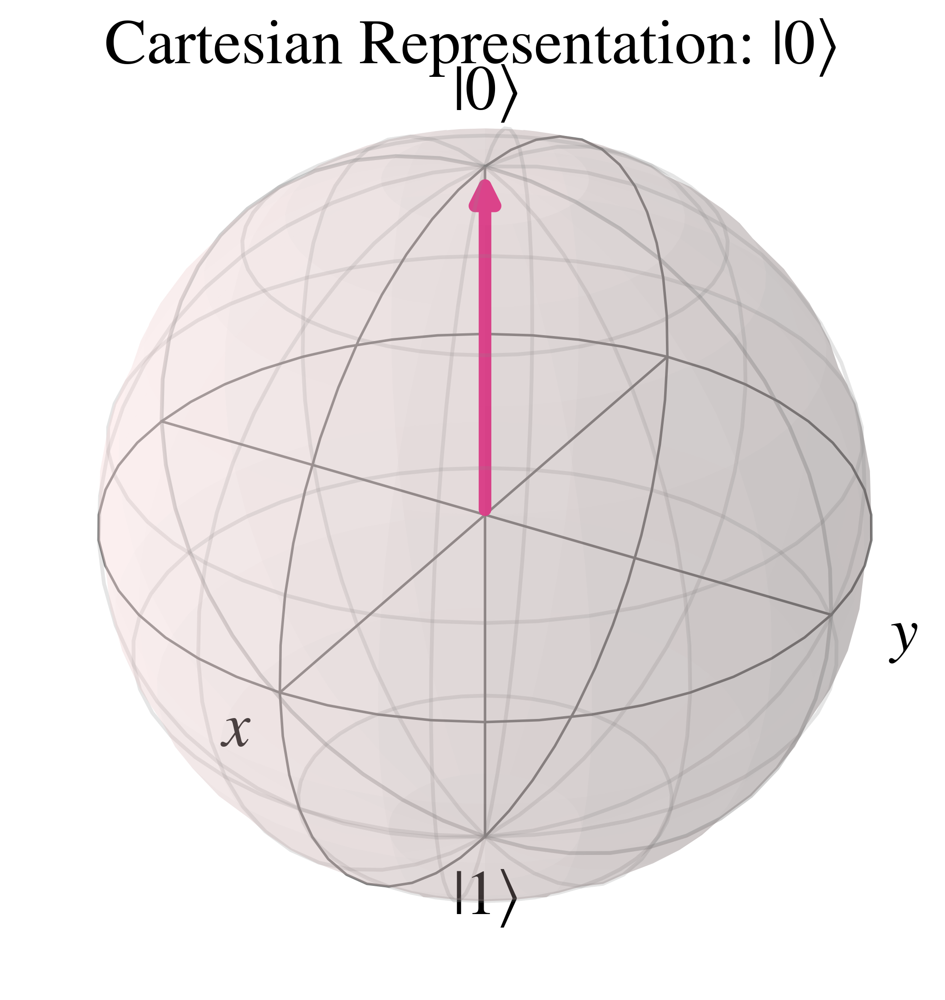

In [50]:
bloch_sphere_0_state_spherical =  plot_bloch_vector([1, 0, 0], coord_type="spherical", title="Spherical Representation: |0⟩")
bloch_sphere_0_state_cartesian =  plot_bloch_vector([0, 0, 1], coord_type="cartesian", title="Cartesian Representation: |0⟩")

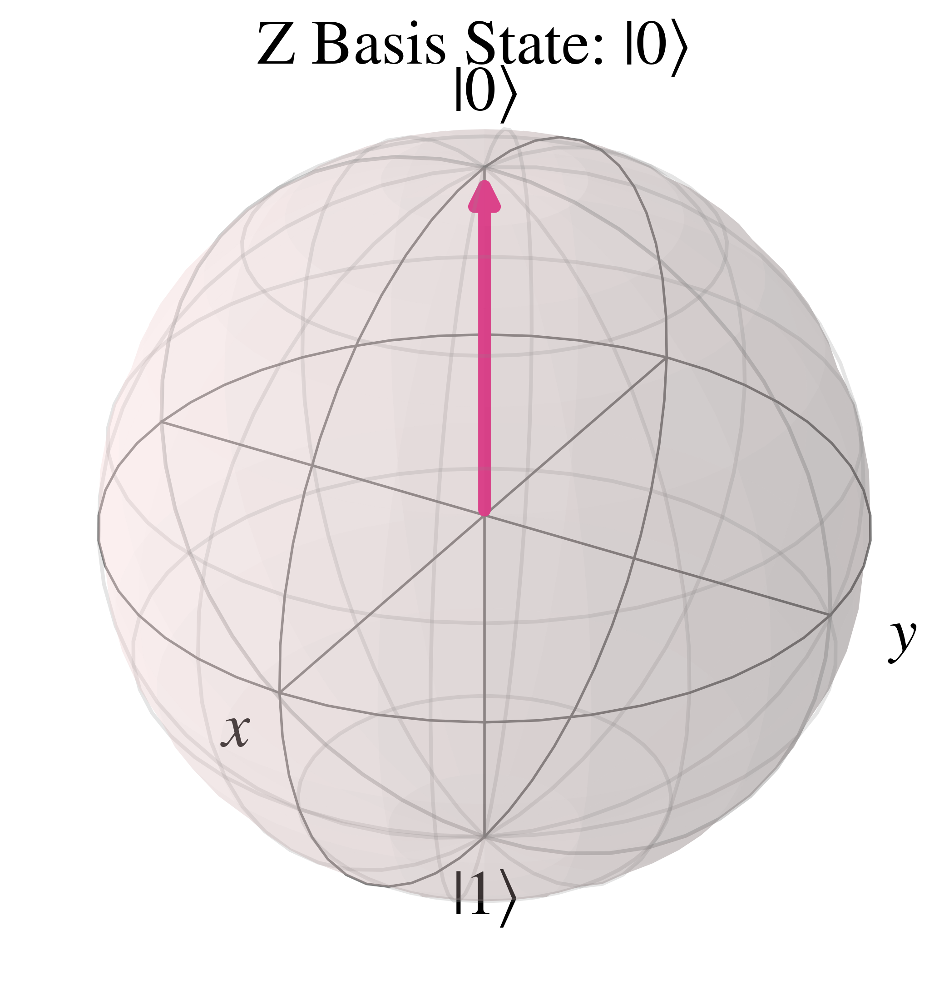

In [51]:
bloch_sphere_0_state = plot_bloch_vector([1, 0, 0], coord_type="spherical", title=r"Z Basis State: $|0\rangle$")
bloch_sphere_0_state.savefig("Figures/Ch1_Basics_Figures/bloch_sphere_computational_basis_0_state.png", bbox_inches="tight")

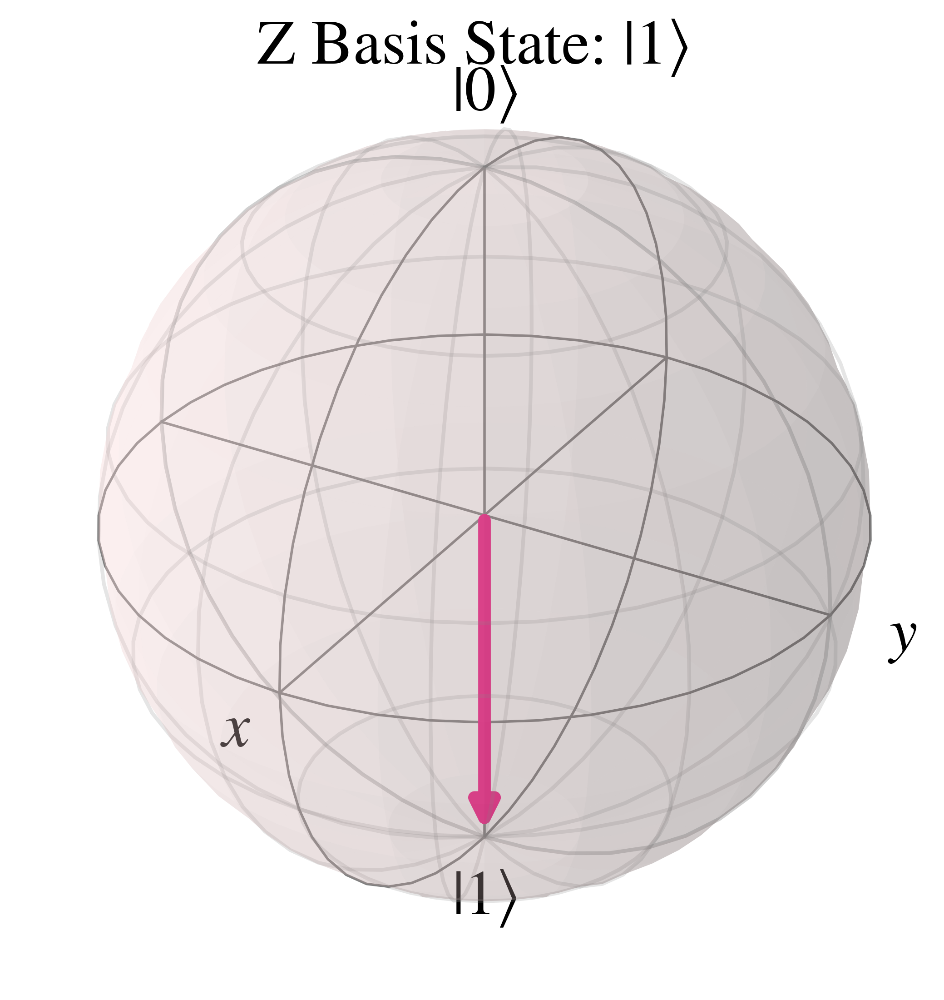

In [52]:
bloch_sphere_1_state = plot_bloch_vector([1, np.pi, 0], coord_type="spherical", title=r"Z Basis State: $|1\rangle$")
bloch_sphere_1_state.savefig("Figures/Ch1_Basics_Figures/bloch_sphere_computational_basis_1_state.png", bbox_inches="tight")

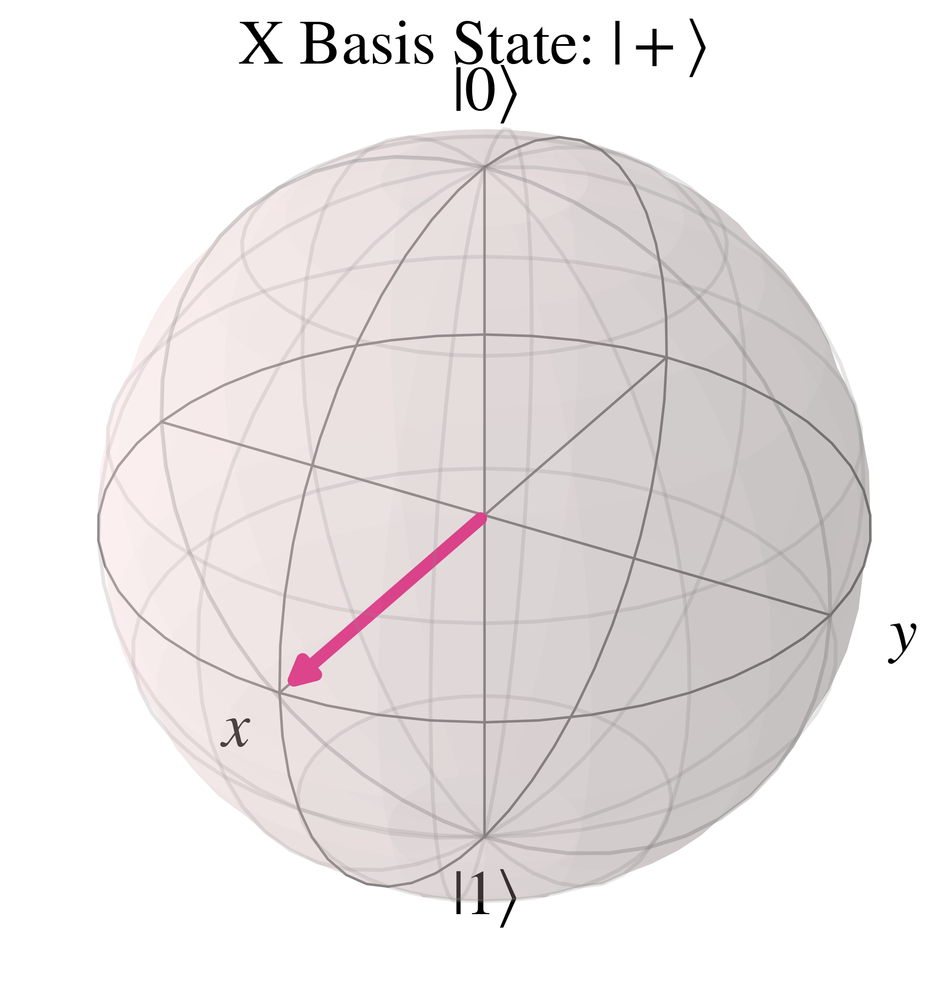

In [53]:
bloch_sphere_plus_state = plot_bloch_vector([1, np.pi/2, 0], coord_type="spherical", title=r"X Basis State: $|+\rangle$")
bloch_sphere_plus_state.savefig("Figures/Ch1_Basics_Figures/bloch_sphere_hadamard_basis_plus_state.png", bbox_inches="tight")

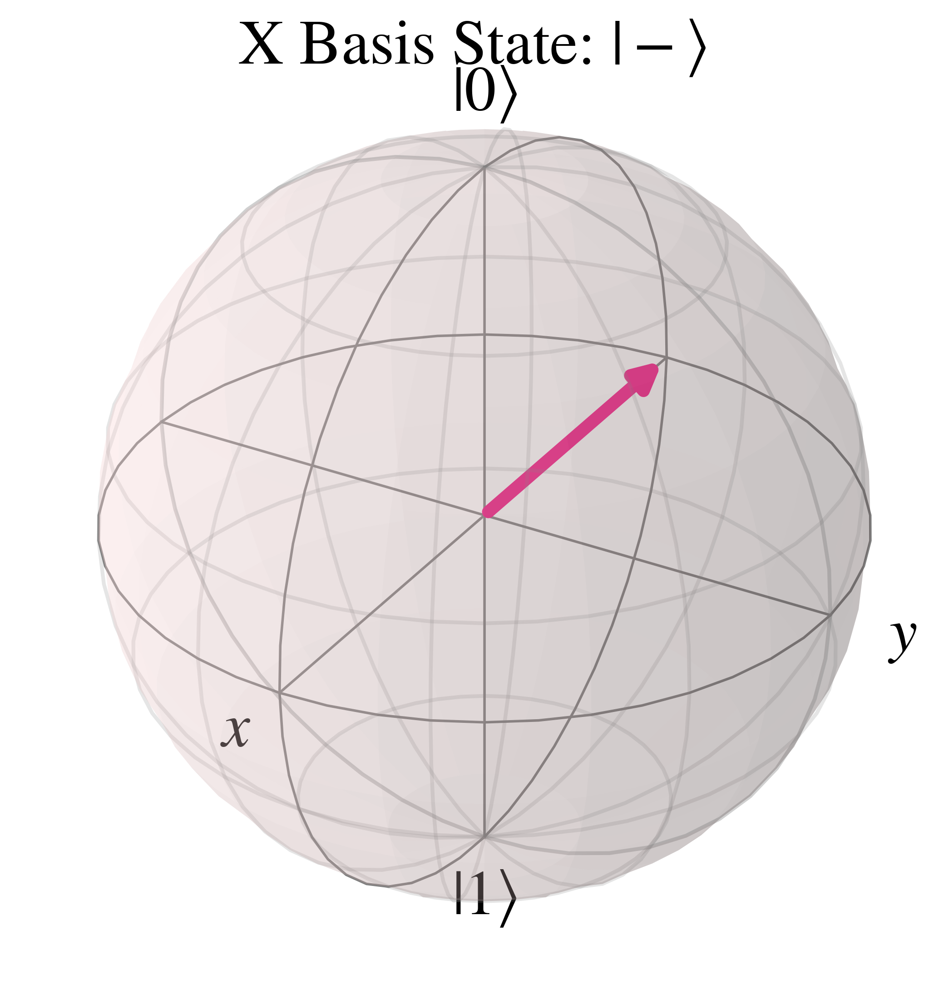

In [54]:
bloch_sphere_minus_state = plot_bloch_vector([1, np.pi/2, np.pi], coord_type="spherical", title=r"X Basis State: $|-\rangle$")
bloch_sphere_minus_state.savefig("Figures/Ch1_Basics_Figures/bloch_sphere_hadamard_basis_minus_state.png", bbox_inches="tight")

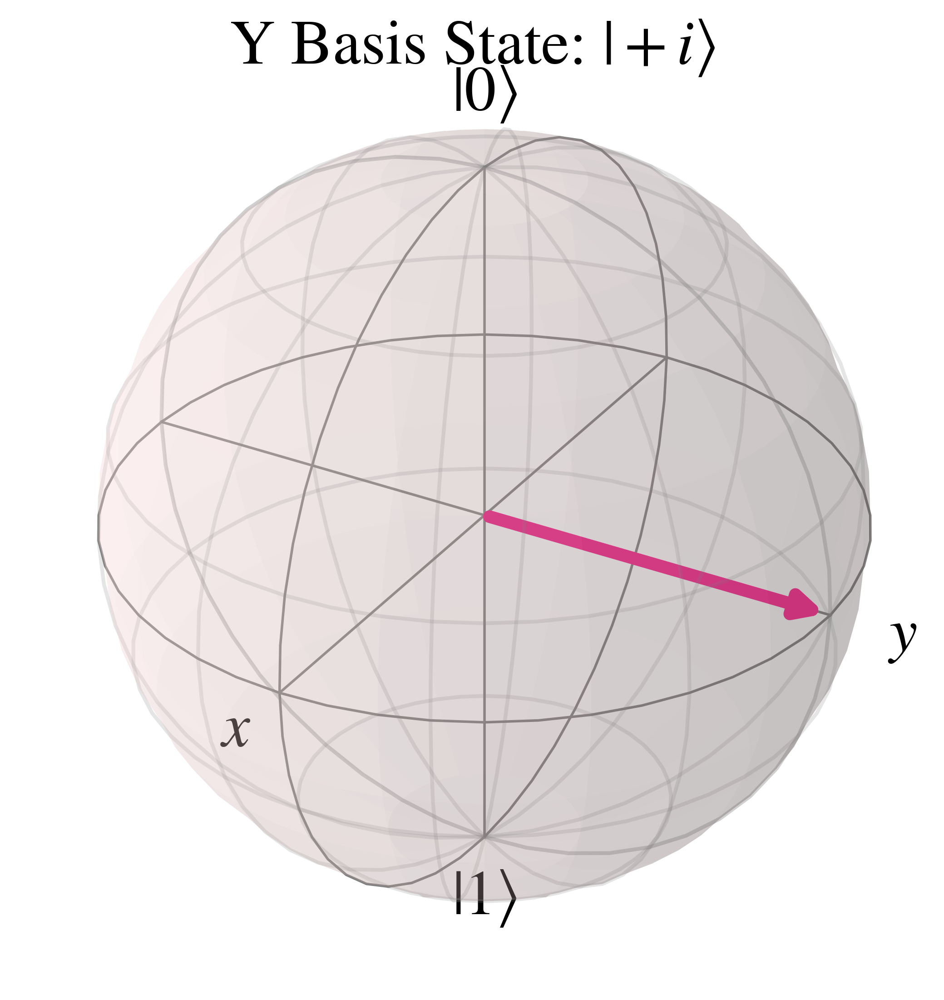

In [55]:
bloch_sphere_i_state = plot_bloch_vector([1, np.pi/2, np.pi/2], coord_type="spherical", title=r"Y Basis State: $|+i\rangle$")
bloch_sphere_i_state.savefig("Figures/Ch1_Basics_Figures/bloch_sphere_circular_basis_i_state.png", bbox_inches="tight")

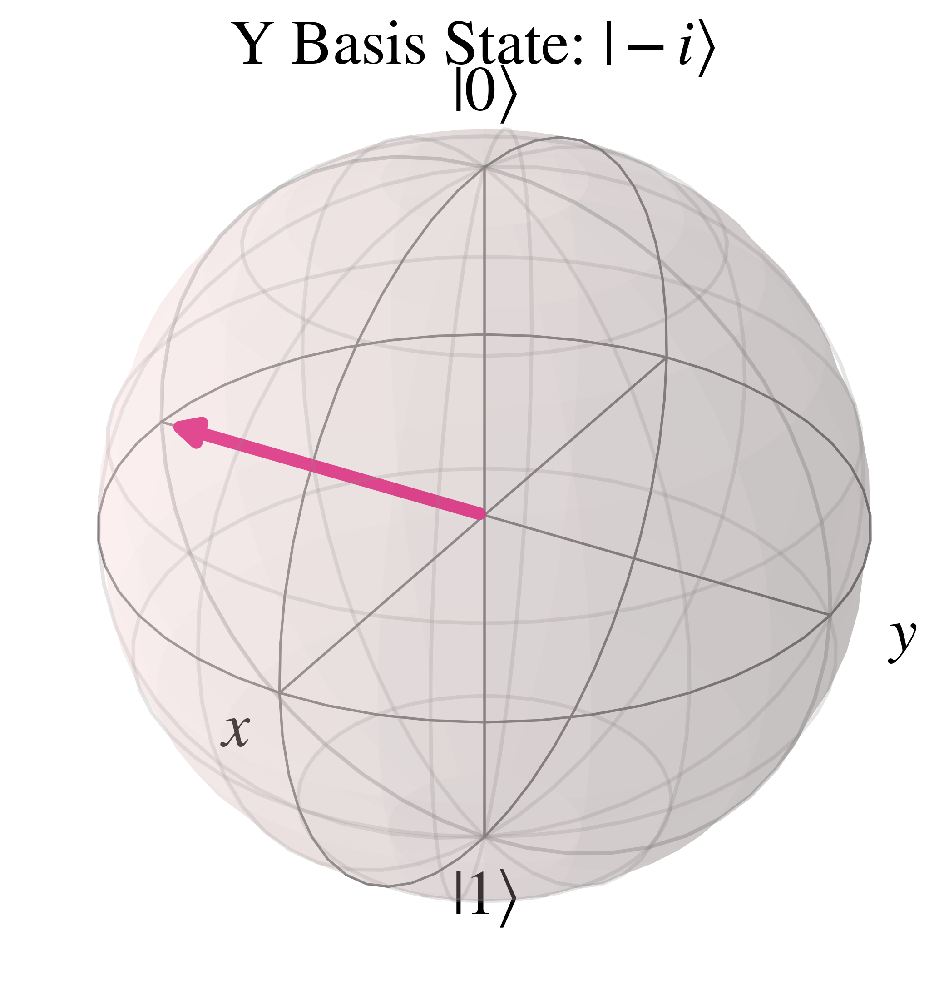

In [56]:
bloch_sphere_minus_i_state = plot_bloch_vector([1, np.pi/2, 3*np.pi/2 ], coord_type="spherical", title=r"Y Basis State: $|-i\rangle$")
bloch_sphere_minus_i_state.savefig("Figures/Ch1_Basics_Figures/bloch_sphere_circular_basis_minus_i_state.png", bbox_inches="tight")

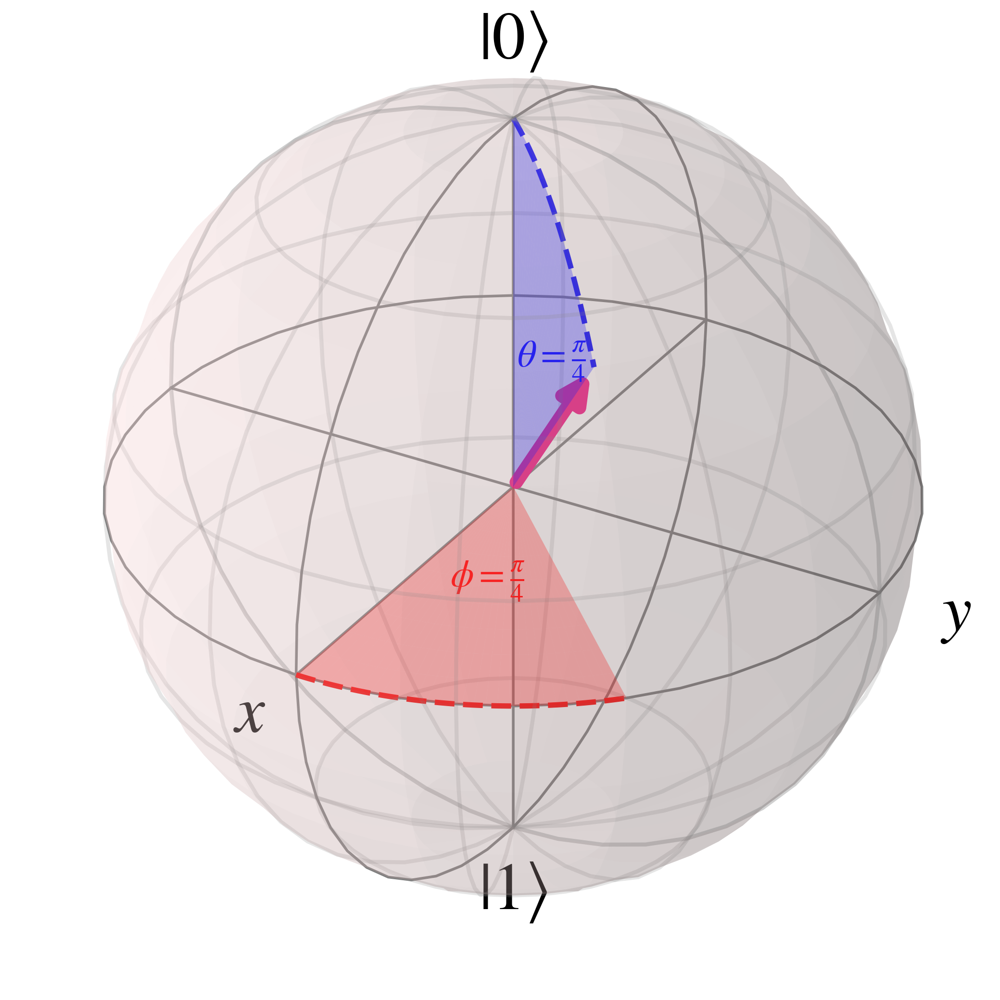

In [57]:
# Note: the following figure made of use AI assistance.

# 1. Define a general quantum state
theta = np.pi / 4  # Polar angle (Probability amplitude)
phi = np.pi / 4    # Azimuthal angle (Relative Phase)

# 2. Generate the base Qiskit Bloch sphere
annotated_bloch_sphere = plot_bloch_vector([1, theta, phi], coord_type='spherical')
ax = annotated_bloch_sphere.axes[0]

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# ==========================================
# --- DRAWING THE PHI ARC & SHADING (Red) --
# ==========================================
# 1. Draw the dashed arc (edge)
arc_phi_angles = np.linspace(0, phi, 50)
q_phi_x = 1 * np.cos(arc_phi_angles)
q_phi_y = 1 * np.sin(arc_phi_angles)
q_phi_z = np.zeros(50)

m_phi_x, m_phi_y, m_phi_z = q_to_m(q_phi_x, q_phi_y, q_phi_z)
ax.plot(m_phi_x, m_phi_y, m_phi_z, color='red', linestyle='dashed', linewidth=2)

# 2. Add the Shaded Surface
r_val = np.linspace(0, 1, 10)
phi_val = np.linspace(0, phi, 30)
R, PHI = np.meshgrid(r_val, phi_val)

Q_SURF_PHI_X = R * np.cos(PHI)
Q_SURF_PHI_Y = R * np.sin(PHI)
Q_SURF_PHI_Z = np.zeros_like(Q_SURF_PHI_X)

M_SURF_PHI_X, M_SURF_PHI_Y, M_SURF_PHI_Z = q_to_m(Q_SURF_PHI_X, Q_SURF_PHI_Y, Q_SURF_PHI_Z)
ax.plot_surface(M_SURF_PHI_X, M_SURF_PHI_Y, M_SURF_PHI_Z, color='red', alpha=0.3, shade=False)

# 3. Text Annotation
text_x, text_y, text_z = q_to_m(0.6 * np.cos(phi / 2), 0.6 * np.sin(phi / 2), 0.05)
ax.text(text_x-0.08, text_y, text_z, r'$\phi = \frac{\pi}{4}$', color='red', fontsize=14)

# ==========================================
# --- DRAWING THE THETA ARC & SHADING (Blue)
# ==========================================
# 1. Draw the dashed arc (edge)
arc_theta_angles = np.linspace(0, theta, 50)
q_theta_x = 1 * np.sin(arc_theta_angles) * np.cos(phi)
q_theta_y = 1 * np.sin(arc_theta_angles) * np.sin(phi)
q_theta_z = 1 * np.cos(arc_theta_angles)

m_theta_x, m_theta_y, m_theta_z = q_to_m(q_theta_x, q_theta_y, q_theta_z)
ax.plot(m_theta_x, m_theta_y, m_theta_z, color='blue', linestyle='dashed', linewidth=2)

# 2. Add the Shaded Surface
theta_val = np.linspace(0, theta, 30)
R_THETA, THETA = np.meshgrid(r_val, theta_val)

Q_SURF_THETA_X = R_THETA * np.sin(THETA) * np.cos(phi)
Q_SURF_THETA_Y = R_THETA * np.sin(THETA) * np.sin(phi)
Q_SURF_THETA_Z = R_THETA * np.cos(THETA)

M_SURF_THETA_X, M_SURF_THETA_Y, M_SURF_THETA_Z = q_to_m(Q_SURF_THETA_X, Q_SURF_THETA_Y, Q_SURF_THETA_Z)
ax.plot_surface(M_SURF_THETA_X, M_SURF_THETA_Y, M_SURF_THETA_Z, color='blue', alpha=0.3, shade=False)

# 3. Text Annotation
text_tx, text_ty, text_tz = q_to_m(0.6 * np.sin(theta / 2) * np.cos(phi), 
                                   0.6 * np.sin(theta / 2) * np.sin(phi), 
                                   0.6 * np.cos(theta / 2))
ax.text(text_tx+0.045, text_ty-0.18, text_tz, r'$\theta = \frac{\pi}{4}$', color='blue', fontsize=14)

annotated_bloch_sphere.savefig("Figures/Ch1_Basics_Figures/annotated_bloch_sphere.png", bbox_inches="tight")



In [58]:
from PIL import Image
created_image_annotated_bloch_sphere= Image.open("Figures/Ch1_Basics_Figures/annotated_bloch_sphere.png")
print("The size of the annotated Bloch sphere is", created_image_annotated_bloch_sphere.size)


The size of the annotated Bloch sphere is (2079, 2079)


<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_37929/230780711.py:43: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_title('3D Spiral of $e^{-i\phi}$ in Complex Plane')


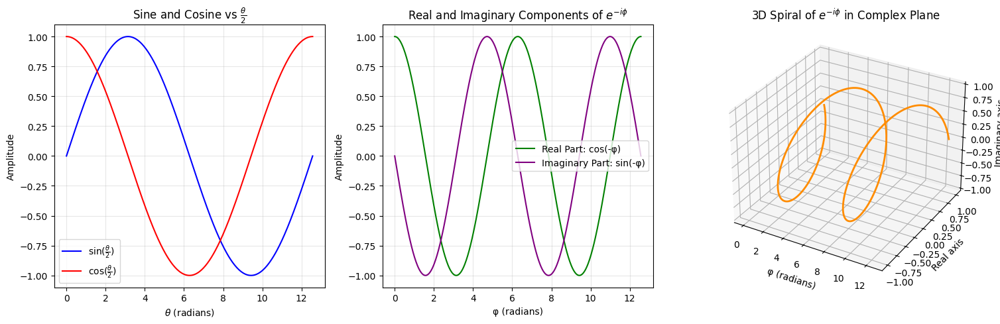

In [8]:
# Note: the following figure made of use AI assistance.

import numpy as np
import matplotlib.pyplot as plt

# Define phi values from 0 to 4*pi (two full cycles)
phi = np.linspace(0, 4 * np.pi, 500)

# Calculate sine, cosine, and exponential
sin_half_theta = np.sin(phi/2)
cos_half_theta = np.cos(phi/2)
exp_minus_i_phi = np.exp(-1j * phi)

# Create a figure with 3 subplots
fig = plt.figure(figsize=(15, 5))

# 1. Sine and Cosine Plot
ax1 = fig.add_subplot(131)
ax1.plot(phi, sin_half_theta, label=r'$\sin(\frac{\theta}{2})$', color='blue')
ax1.plot(phi, cos_half_theta, label=r'$\cos(\frac{\theta}{2})$', color='red')
ax1.set_xlabel(r'$\theta$ (radians)')
ax1.set_ylabel('Amplitude')
ax1.set_title(r'Sine and Cosine vs $\frac{\theta}{2}$')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Real and Imaginary parts of e^{-iφ}
ax2 = fig.add_subplot(132)
ax2.plot(phi, np.real(exp_minus_i_phi), label='Real Part: cos(-φ)', color='green')
ax2.plot(phi, np.imag(exp_minus_i_phi), label='Imaginary Part: sin(-φ)', color='purple')
ax2.set_xlabel('φ (radians)')
ax2.set_ylabel('Amplitude')
ax2.set_title(r'Real and Imaginary Components of $e^{-i\phi}$')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. 3D representation of e^{-iφ}
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(phi, np.real(exp_minus_i_phi), np.imag(exp_minus_i_phi), color='darkorange', linewidth=2)
ax3.set_xlabel('φ (radians)')
ax3.set_ylabel('Real axis')
ax3.set_zlabel('Imaginary axis')
ax3.set_title('3D Spiral of $e^{-i\phi}$ in Complex Plane')

plt.tight_layout()
plt.savefig('trig_exp_plots.png', dpi=500)

/var/folders/9k/jzqcwwz92p35vtq6ypw0mkh40000gn/T/ipykernel_37929/1868759548.py:118: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(w_pad=4.0)


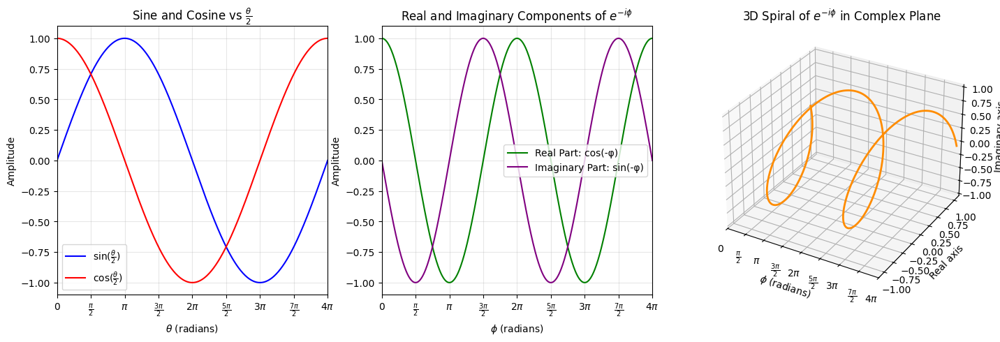

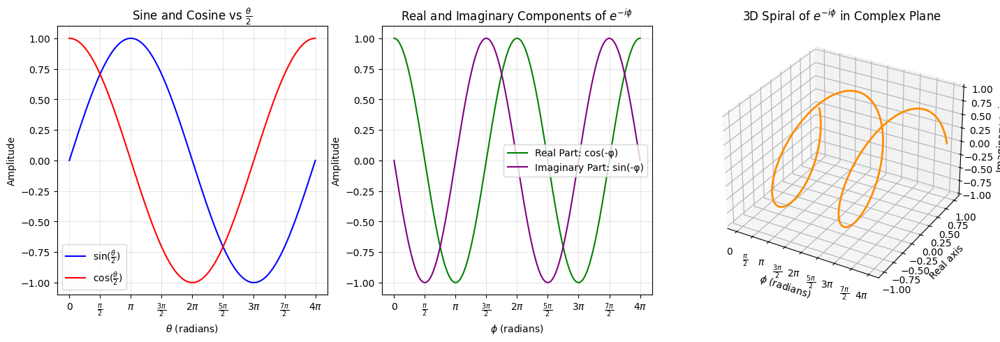

In [23]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt

# Define phi values from 0 to 4*pi (two full cycles)
phi = np.linspace(0, 4 * np.pi, 500)

# Calculate sine, cosine, and exponential
sin_half_theta = np.sin(phi/2)
cos_half_theta = np.cos(phi/2)
exp_minus_i_phi = np.exp(-1j * phi)

# Define tick marks and LaTeX labels for multiples of pi/2
tick_vals = [0, np.pi/2, np.pi, 1.5*np.pi, 2*np.pi, 2.5*np.pi, 3*np.pi, 3.5*np.pi, 4*np.pi]
tick_labels = ['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$', 
               r'$\frac{5\pi}{2}$', r'$3\pi$', r'$\frac{7\pi}{2}$', r'$4\pi$']

# FIX 1: Make the figure wider (changed width from 15 to 17)
fig = plt.figure(figsize=(17, 5))

# 1. Sine and Cosine Plot
ax1 = fig.add_subplot(131)
ax1.plot(phi, sin_half_theta, label=r'$\sin(\frac{\theta}{2})$', color='blue')
ax1.plot(phi, cos_half_theta, label=r'$\cos(\frac{\theta}{2})$', color='red')
ax1.set_xlabel(r'$\theta$ (radians)')
ax1.set_ylabel('Amplitude')
ax1.set_title(r'Sine and Cosine vs $\frac{\theta}{2}$')
ax1.set_xticks(tick_vals)
ax1.set_xlim(left=0, right=4*np.pi)
ax1.set_xticklabels(tick_labels)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Real and Imaginary parts of e^{-iφ}
ax2 = fig.add_subplot(132)
ax2.plot(phi, np.real(exp_minus_i_phi), label='Real Part: cos(-φ)', color='green')
ax2.plot(phi, np.imag(exp_minus_i_phi), label='Imaginary Part: sin(-φ)', color='purple')
ax2.set_xlabel(r'$\phi$ (radians)')
ax2.set_ylabel('Amplitude')
ax2.set_title(r'Real and Imaginary Components of $e^{-i\phi}$')
ax2.set_xticks(tick_vals)
ax2.set_xticklabels(tick_labels)
ax2.set_xlim(left=0, right=4*np.pi)
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. 3D representation of e^{-iφ}
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(phi, np.real(exp_minus_i_phi), np.imag(exp_minus_i_phi), color='darkorange', linewidth=2)
ax3.set_xlabel(r'$\phi$ (radians)')
ax3.set_ylabel('Real axis')
ax3.set_zlabel('Imaginary axis')
ax3.set_title(r'3D Spiral of $e^{-i\phi}$ in Complex Plane')
ax3.set_xticks(tick_vals)
ax3.set_xlim(left=0, right=4*np.pi)
ax3.set_xticklabels(tick_labels)

# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt

# Define phi values from 0 to 4*pi (two full cycles)
phi = np.linspace(0, 4 * np.pi, 500)

# Calculate sine, cosine, and exponential
sin_half_theta = np.sin(phi/2)
cos_half_theta = np.cos(phi/2)
exp_minus_i_phi = np.exp(-1j * phi)

# Define tick marks and LaTeX labels for multiples of pi/2
tick_vals = [0, np.pi/2, np.pi, 1.5*np.pi, 2*np.pi, 2.5*np.pi, 3*np.pi, 3.5*np.pi, 4*np.pi]
tick_labels = ['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$', 
               r'$\frac{5\pi}{2}$', r'$3\pi$', r'$\frac{7\pi}{2}$', r'$4\pi$']

# FIX 1: Make the figure wider (changed width from 15 to 17)
fig = plt.figure(figsize=(17, 5))

# 1. Sine and Cosine Plot
ax1 = fig.add_subplot(131)
ax1.plot(phi, sin_half_theta, label=r'$\sin(\frac{\theta}{2})$', color='blue')
ax1.plot(phi, cos_half_theta, label=r'$\cos(\frac{\theta}{2})$', color='red')
ax1.set_xlabel(r'$\theta$ (radians)')
ax1.set_ylabel('Amplitude')
ax1.set_title(r'Sine and Cosine vs $\frac{\theta}{2}$')
ax1.set_xticks(tick_vals)
ax1.set_xticklabels(tick_labels)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Real and Imaginary parts of e^{-iφ}
ax2 = fig.add_subplot(132)
ax2.plot(phi, np.real(exp_minus_i_phi), label='Real Part: cos(-φ)', color='green')
ax2.plot(phi, np.imag(exp_minus_i_phi), label='Imaginary Part: sin(-φ)', color='purple')
ax2.set_xlabel(r'$\phi$ (radians)')
ax2.set_ylabel('Amplitude')
ax2.set_title(r'Real and Imaginary Components of $e^{-i\phi}$')
ax2.set_xticks(tick_vals)
ax2.set_xticklabels(tick_labels)
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. 3D representation of e^{-iφ}
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(phi, np.real(exp_minus_i_phi), np.imag(exp_minus_i_phi), color='darkorange', linewidth=2)
ax3.set_xlabel(r'$\phi$ (radians)')
ax3.set_ylabel('Real axis')
ax3.set_zlabel('Imaginary axis')
ax3.set_title(r'3D Spiral of $e^{-i\phi}$ in Complex Plane')
ax3.set_xticks(tick_vals)
ax3.set_xticklabels(tick_labels)

# Reduced labelpad so it doesn't fly off the screen
ax3.zaxis.labelpad = 5 

# FIX 2: Force a minimum horizontal space (w_pad) between subplots
plt.tight_layout(w_pad=4.0)

# FIX 3: Add pad_inches to give a guaranteed border around the saved image
plt.savefig('Figures/CH1_Basics_Figures/trig_exp_plots.png', bbox_inches='tight', pad_inches=0.3)
plt.show()

# Circuit Representation (with Bloch Sphere)
## Single Qubit gates

In [40]:
from qiskit import QuantumCircuit, QuantumRegister

# 1. Define our Unicode inputs
label_x = "X Input: α|0⟩ + β|1⟩"
label_y = "Y Input: α|0⟩ + β|1⟩"
label_z = "Z Input: α|0⟩ + β|1⟩"

qr_x = QuantumRegister(1, name=label_x)
qr_y = QuantumRegister(1, name=label_y)
qr_z = QuantumRegister(1, name=label_z)


# 2. Build the exact, clean logical circuit
qc_pauli = QuantumCircuit(qr_x, qr_y, qr_z)
qc_pauli.barrier()
qc_pauli.x(qr_x)
qc_pauli.y(qr_y)
qc_pauli.z(qr_z)

# 3. Draw the circuit (returns a Matplotlib Figure)
fig_pauli = qc_pauli.draw(output='mpl', scale=1.5, initial_state=False)

# ==========================================
# --- THE MATPLOTLIB ANNOTATION TRICK ------
# ==========================================
# Grab the drawing canvas (Axes)
ax = fig_pauli.axes[0]

# Widen the x-axis limits so our text doesn't get cut off
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 1.5)

# Define a nice font style to match the Qiskit drawing
font_style = {'fontsize': 25, 'verticalalignment': 'center'}



# Qiskit places the top wire at y=0, middle at y=-1, and bottom at y=-2.
# We place our text just slightly to the right of the circuit's end (x_max + 0.2)
ax.text(x_max + 0.2,  0, r"X Output: from qiskit import QuantumCircuit, QuantumRegister

# 1. Define our Unicode inputs
label_x = "X Input: α|0⟩ + β|1⟩"
label_y = "Y Input: α|0⟩ + β|1⟩"
label_z = "Z Input: α|0⟩ + β|1⟩"

qr_x = QuantumRegister(1, name=label_x)
qr_y = QuantumRegister(1, name=label_y)
qr_z = QuantumRegister(1, name=label_z)


# 2. Build the exact, clean logical circuit
qc_pauli = QuantumCircuit(qr_x, qr_y, qr_z)
qc_pauli.barrier()
qc_pauli.x(qr_x)
qc_pauli.y(qr_y)
qc_pauli.z(qr_z)

# 3. Draw the circuit (returns a Matplotlib Figure)
fig_pauli = qc_pauli.draw(output='mpl', scale=1.5, initial_state=False)

# ==========================================
# --- THE MATPLOTLIB ANNOTATION TRICK ------
# ==========================================
# Grab the drawing canvas (Axes)
ax = fig_pauli.axes[0]

# Widen the x-axis limits so our text doesn't get cut off
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 1.5)

# Define a nice font style to match the Qiskit drawing
font_style = {'fontsize': 25, 'verticalalignment': 'center'}



# Qiskit places the top wire at y=0, middle at y=-1, and bottom at y=-2.
# We place our text just slightly to the right of the circuit's end (x_max + 0.2)
ax.text(x_max + 0.2,  0, r"$\beta|0\rangle$ + $\alpha|1\rangle$", **font_style)       # Top wire (X)
ax.text(x_max + 0.2, -1, r"$-i\beta|0\rangle$ + $i\alpha|1\rangle$", **font_style)   # Middle wire (Y)
ax.text(x_max + 0.2, -2, r"$\alpha|0\rangle$ - $\beta|1\rangle$", **font_style)      # Bottom wire (Z)
# ==========================================

# Save and display!
fig_pauli.savefig('pauli_effects.png', dpi=300, bbox_inches='tight')
fig_pauli + α|1⟩", **font_style)       # Top wire (X)
ax.text(x_max + 0.2, -1, r"Y Output: -iβ|0⟩ + iα|1⟩", **font_style)   # Middle wire (Y)
ax.text(x_max + 0.2, -2, r"Z Output: α|0⟩ - β|1⟩", **font_style)      # Bottom wire (Z)
# ==========================================

# Save and display!
fig_pauli.savefig('pauli_effects.png', dpi=300, bbox_inches='tight')
fig_pauli

SyntaxError: unterminated string literal (detected at line 40) (732508237.py, line 40)

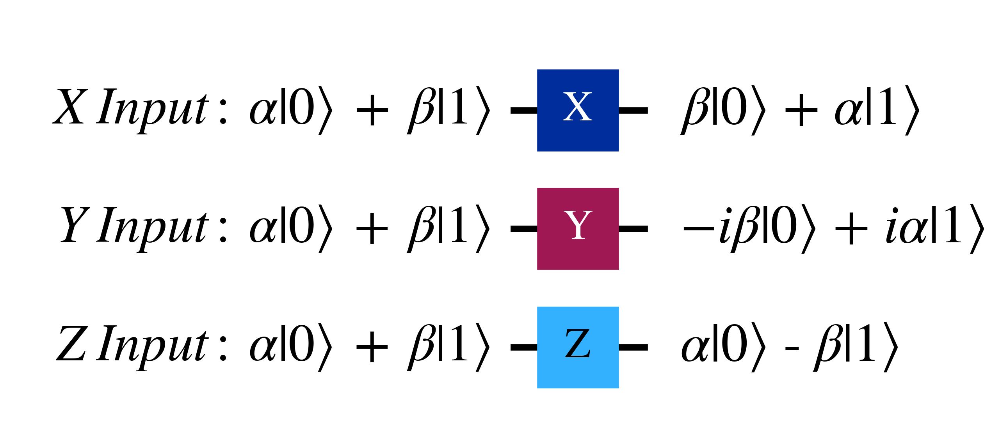

In [ ]:
# 1. Define our Unicode inputs
label_x = "X Input: α|0⟩ + β|1⟩"
label_y = "Y Input: α|0⟩ + β|1⟩"
label_z = "Z Input: α|0⟩ + β|1⟩"

qr_x = QuantumRegister(1, name=label_x)
qr_y = QuantumRegister(1, name=label_y)
qr_z = QuantumRegister(1, name=label_z)


# 2. Build the exact, clean logical circuit
qc_pauli = QuantumCircuit(qr_x, qr_y, qr_z)
#qc_pauli.barrier()
qc_pauli.x(qr_x)
qc_pauli.y(qr_y)
qc_pauli.z(qr_z)

# 3. Draw the circuit (returns a Matplotlib Figure)
fig_pauli = qc_pauli.draw(output='mpl', scale=1.5, initial_state=False)

# ==========================================
# --- THE MATPLOTLIB ANNOTATION TRICK ------
# ==========================================
# Grab the drawing canvas (Axes)
ax = fig_pauli.axes[0]

# Widen the x-axis limits so our text doesn't get cut off
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 1.5)

# Define a nice font style to match the Qiskit drawing
font_style = {'fontsize': 25, 'verticalalignment': 'center'}


# Qiskit places the top wire at y=0, middle at y=-1, and bottom at y=-2.
# We place our text just slightly to the right of the circuit's end (x_max + 0.2)
ax.text(x_max + 0.2,  0, r"$\beta|0\rangle$ + $\alpha|1\rangle$", **font_style)       # Top wire (X)
ax.text(x_max + 0.2, -1, r"$-i\beta|0\rangle$ + $i\alpha|1\rangle$", **font_style)   # Middle wire (Y)
ax.text(x_max + 0.2, -2, r"$\alpha|0\rangle$ - $\beta|1\rangle$", **font_style)      # Bottom wire (Z)
# ==========================================

# Save and display!
fig_pauli.savefig(figure_directory+'pauli_gate_circuit_demonstration_on_general_dirac_state.png', bbox_inches='tight')
#fig_pauli

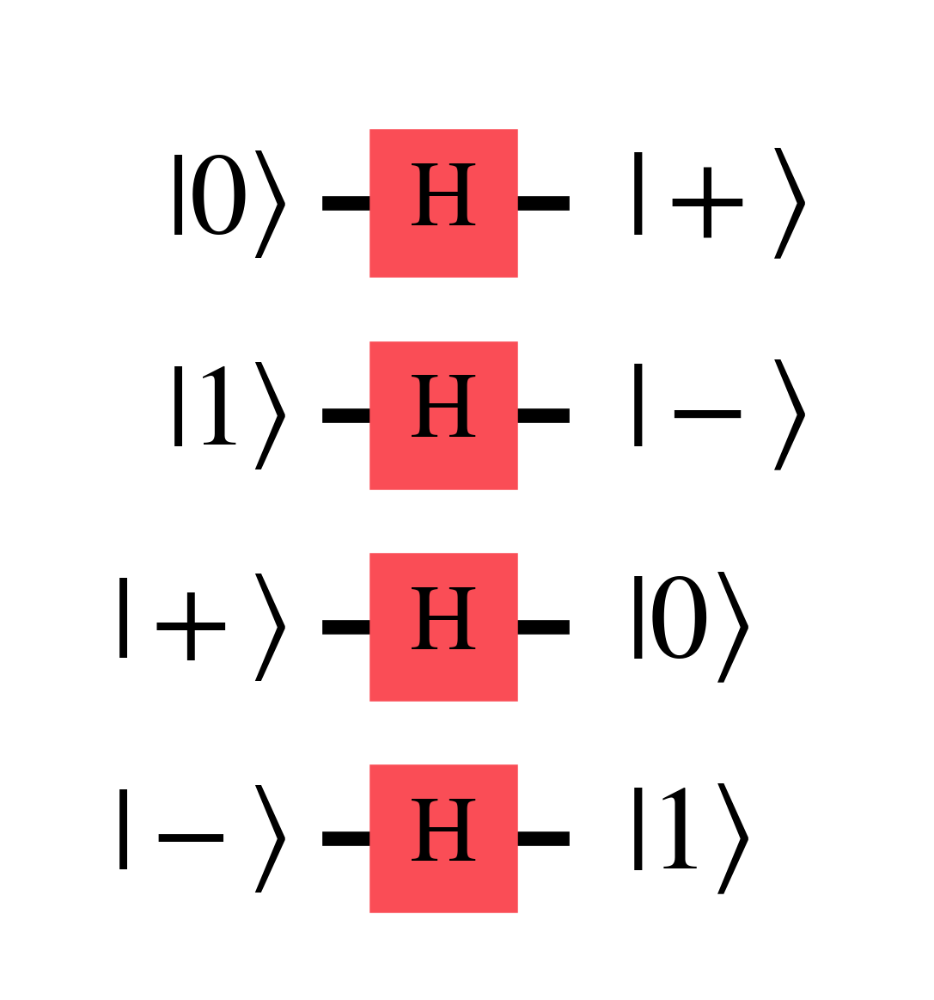

In [51]:
from qiskit import QuantumCircuit, QuantumRegister

qr_0 = QuantumRegister(1, '|0⟩')
qr_1 = QuantumRegister(1, '|1⟩')
qr_plus = QuantumRegister(1, '|+⟩')
qr_minus = QuantumRegister(1, '|-⟩')

qc_hadamard_demonstration = QuantumCircuit(qr_0, qr_1, qr_plus, qr_minus)
qc_hadamard_demonstration.h(qr_0)
qc_hadamard_demonstration.h(qr_1)
qc_hadamard_demonstration.h(qr_plus)
qc_hadamard_demonstration.h(qr_minus)

fig_hadamard_demonstration = qc_hadamard_demonstration.draw(output='mpl', scale=1.5, initial_state=False)
ax = fig_hadamard_demonstration.axes[0]
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 1.5)

font_style = {'fontsize': 25, 'verticalalignment': 'center'}
ax.text(x_max + 0.2, 0, r'$|+\rangle$', **font_style)
ax.text(x_max + 0.2, -1, r'$|-\rangle$', **font_style)
ax.text(x_max + 0.2, -2, r'$|0\rangle$', **font_style)
ax.text(x_max + 0.2, -3, r'$|1\rangle$', **font_style)

fig_hadamard_demonstration.savefig(figure_directory+'hadamard_gate_circuit_demonstration.png', dpi=300, bbox_inches='tight')

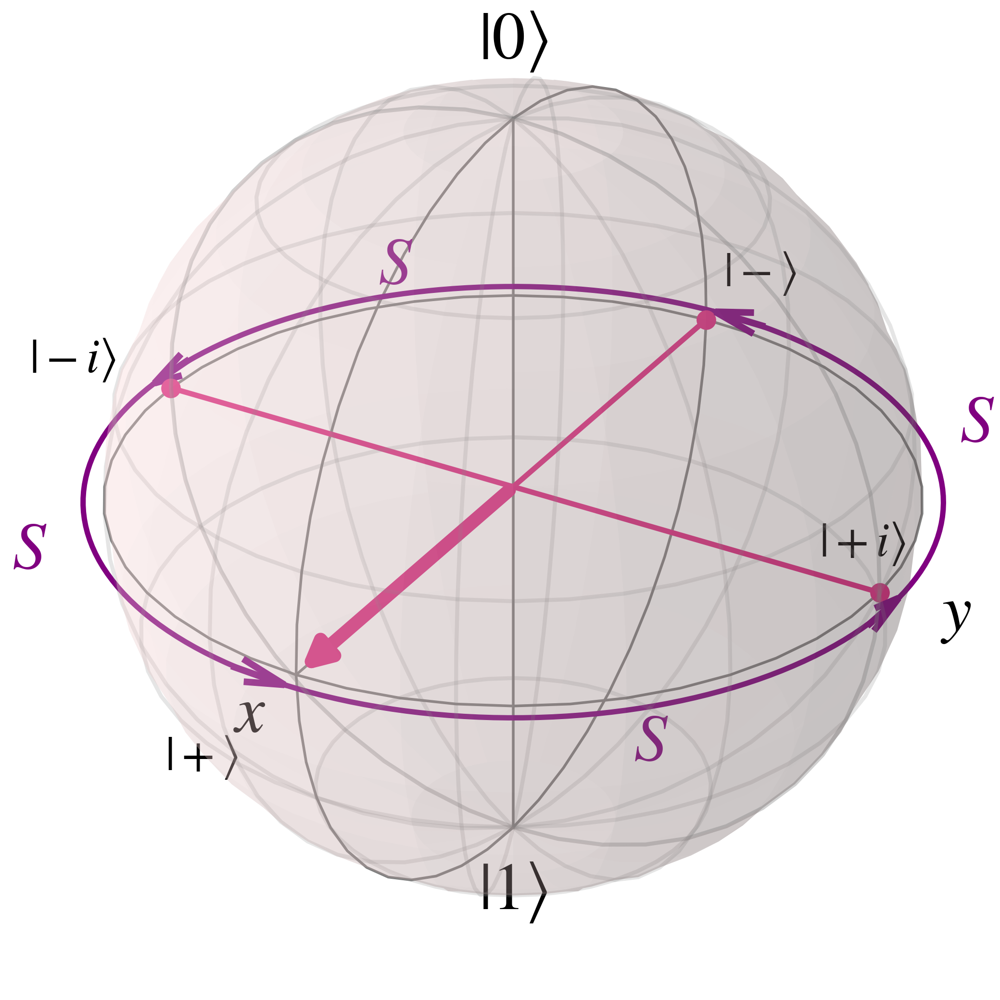

In [71]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# 1. Start with a sphere showing the initial |+> state
fig_s_gate = plot_bloch_vector([1, np.pi/2, 0], coord_type='spherical')
ax = fig_s_gate.axes[0]

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# 2. Draw the other three states on the equator
vector_color = '#dc267f'

states = {
    r'$|+i\rangle$': (0, 1, 0),
    r'$|-\rangle$': (-1, 0, 0),
    r'$|-i\rangle$': (0, -1, 0)
}

for label, (qx, qy, qz) in states.items():
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.plot([0, mx], [0, my], [0, mz], color=vector_color, linewidth=2)
    ax.scatter([mx], [my], [mz], color=vector_color, s=40)

# 3. Add text labels for all four states
labels = {
    r'$|+\rangle$': (1.4, 0, 0),
    r'$|+i\rangle$': (0, 0.95, 0.12),
    r'$|-\rangle$': (-1.3, 0, 0),
    r'$|-i\rangle$': (0, -1.3, 0)
}

font_style = {'fontsize': 18, 'verticalalignment': 'center', 'horizontalalignment': 'center'}
for text, (qx, qy, qz) in labels.items():
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.text(mx, my, mz, text, **font_style)

# =========================================================================
# --- MODIFIED: Fixed the 3D Quiver Arrowhead Arguments ---
# =========================================================================
ring_color = 'purple'
radius = 1.05

def draw_equatorial_arc_with_arrow(start_phi, end_phi):
    # 1. Draw solid arc segment
    phi_angles = np.linspace(start_phi, end_phi, 50)
    q_arc_x = radius * np.cos(phi_angles)
    q_arc_y = radius * np.sin(phi_angles)
    q_arc_z = np.zeros(50)
    m_arc_x, m_arc_y, m_arc_z = q_to_m(q_arc_x, q_arc_y, q_arc_z)
    
    ax.plot(m_arc_x, m_arc_y, m_arc_z, color=ring_color, linewidth=2)

    # 2. Draw arrowhead at the end point using the correct 3D arguments
    qx_head = radius * np.cos(end_phi)
    qy_head = radius * np.sin(end_phi)
    mx_head, my_head, mz_head = q_to_m(qx_head, qy_head, 0)
    
    phi_prev = end_phi - 0.1
    qx_prev = radius * np.cos(phi_prev)
    qy_prev = radius * np.sin(phi_prev)
    mx_prev, my_prev, mz_prev = q_to_m(qx_prev, qy_prev, 0)
    
    v_dir = (mx_head - mx_prev, my_head - my_prev, mz_head - mz_prev)
    v_dir_norm = v_dir / np.linalg.norm(v_dir)
    
    # FIXED: Replaced headlength/headwidth with arrow_length_ratio and added pivot='tip'
    ax.quiver(mx_head, my_head, mz_head, v_dir_norm[0], v_dir_norm[1], v_dir_norm[2], 
              color=ring_color, length=0.15, normalize=False, 
              arrow_length_ratio=0.8, pivot='tip', linewidth=2.5)

# Quadrant 1: |+> to |+i>
draw_equatorial_arc_with_arrow(0, np.pi/2)
# Quadrant 2: |+i> to |->
draw_equatorial_arc_with_arrow(np.pi/2, np.pi)
# Quadrant 3: |-> to |-i>
draw_equatorial_arc_with_arrow(np.pi, 1.5*np.pi)
# Quadrant 4: |-i> to |+>
draw_equatorial_arc_with_arrow(1.5*np.pi, 2*np.pi)
# =========================================================================

# 5. Add "S" labels
s_label_angles = [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4]
for angle in s_label_angles:
    qx = 1.2 * np.cos(angle)
    qy = 1.2 * np.sin(angle)
    mx, my, mz = q_to_m(qx, qy, 0)
    ax.text(mx, my, mz, r'$S$', color=ring_color, fontsize=25, fontweight='bold',
            ha='center', va='center')

plt.savefig(figure_directory+'s_gate_rotations.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

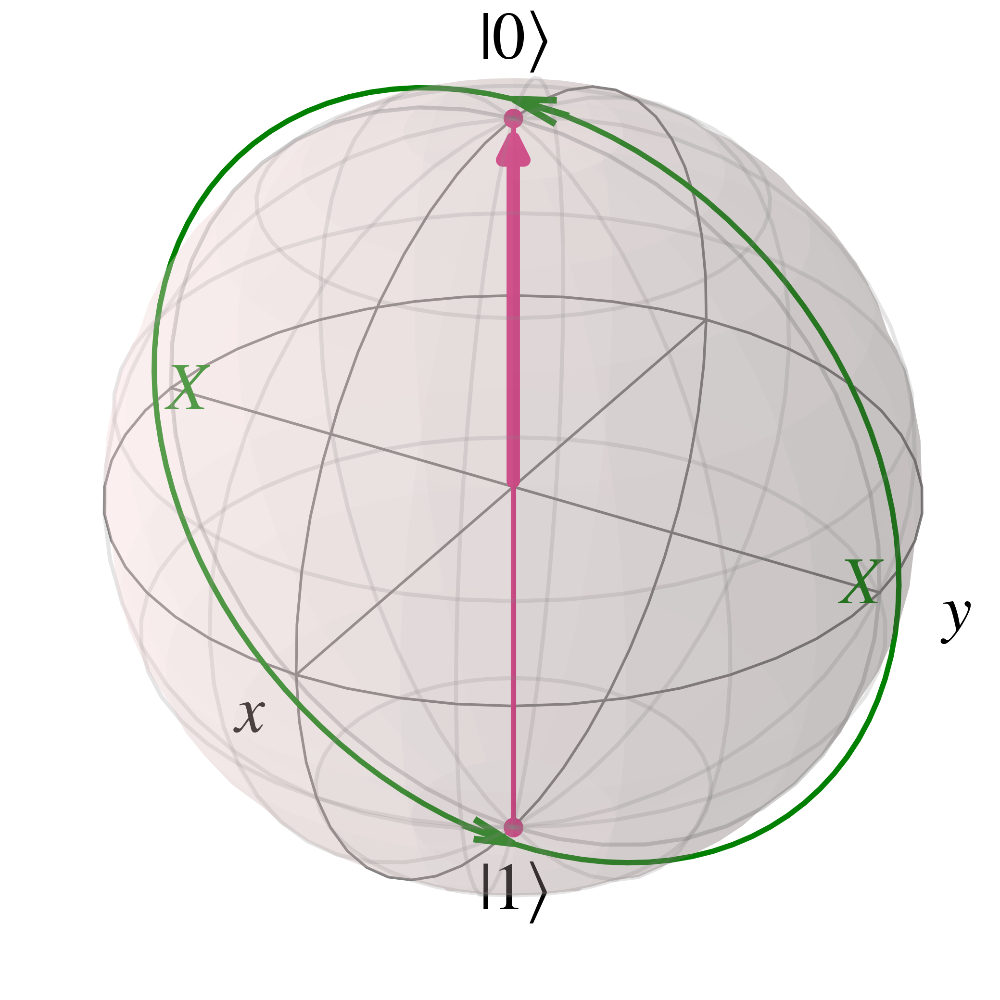

In [85]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# 1. Start with a sphere showing the initial |0> state at the North Pole
# Cartesian coordinates for |0>: x=0, y=0, z=1
fig_x_gate = plot_bloch_vector([0, 0, 1], coord_type='cartesian')
ax = fig_x_gate.axes[0]

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# 2. Draw the |0> and |1> state vectors
vector_color = '#dc267f'

states = {
    r'$|0\rangle$': (0, 0, 1),
    r'$|1\rangle$': (0, 0, -1)
}

for label, (qx, qy, qz) in states.items():
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.plot([0, mx], [0, my], [0, mz], color=vector_color, linewidth=2)
    ax.scatter([mx], [my], [mz], color=vector_color, s=40)


# =========================================================================
# --- DRAWING THE X-GATE ROTATION (Y-Z PLANE) ---
# =========================================================================
ring_color = 'green'
radius = 1.05

def draw_yz_arc_with_arrow(start_theta, end_theta):
    # 1. Draw solid arc segment in the Y-Z plane
    theta_angles = np.linspace(start_theta, end_theta, 50)
    q_arc_x = np.zeros(50)
    # The X rotation moves the state through the -Y axis first
    q_arc_y = -radius * np.sin(theta_angles) 
    q_arc_z = radius * np.cos(theta_angles)
    m_arc_x, m_arc_y, m_arc_z = q_to_m(q_arc_x, q_arc_y, q_arc_z)
    
    ax.plot(m_arc_x, m_arc_y, m_arc_z, color=ring_color, linewidth=2)

    # 2. Draw 3D arrowhead at the end point
    qx_head = 0
    qy_head = -radius * np.sin(end_theta)
    qz_head = radius * np.cos(end_theta)
    mx_head, my_head, mz_head = q_to_m(qx_head, qy_head, qz_head)
    
    theta_prev = end_theta - 0.1
    qx_prev = 0
    qy_prev = -radius * np.sin(theta_prev)
    qz_prev = radius * np.cos(theta_prev)
    mx_prev, my_prev, mz_prev = q_to_m(qx_prev, qy_prev, qz_prev)
    
    v_dir = (mx_head - mx_prev, my_head - my_prev, mz_head - mz_prev)
    v_dir_norm = v_dir / np.linalg.norm(v_dir)
    
    # 3D Quiver arrowhead
    ax.quiver(mx_head, my_head, mz_head, v_dir_norm[0], v_dir_norm[1], v_dir_norm[2], 
              color=ring_color, length=0.15, normalize=False, 
              arrow_length_ratio=0.8, pivot='tip', linewidth=2.5)

# --- Define the two X-gate rotation semicircles (180 degrees each) ---
# First X Gate: |0> to |1> (theta from 0 to pi)
draw_yz_arc_with_arrow(0, np.pi)

# Second X Gate: |1> back to |0> (theta from pi to 2pi)
draw_yz_arc_with_arrow(np.pi, 2*np.pi)
# =========================================================================

# 5. Add "X" labels at the 90-degree midpoints
x_label_angles = [np.pi/2, 3*np.pi/2]
for angle in x_label_angles:
    qx = 0
    qy = -0.95 * np.sin(angle)
    qz = 0.95 * np.cos(angle)
    mx, my, mz = q_to_m(qx, qy, qz)
    
    ax.text(mx, my, mz, r'$X$', color=ring_color, fontsize=25, fontweight='bold',
            ha='center', va='center')

# Save cleanly to avoid cutoffs
plt.savefig(figure_directory+'x_gate_rotations.png', bbox_inches='tight', pad_inches=0.1)

# Display once and clear memory
plt.show()

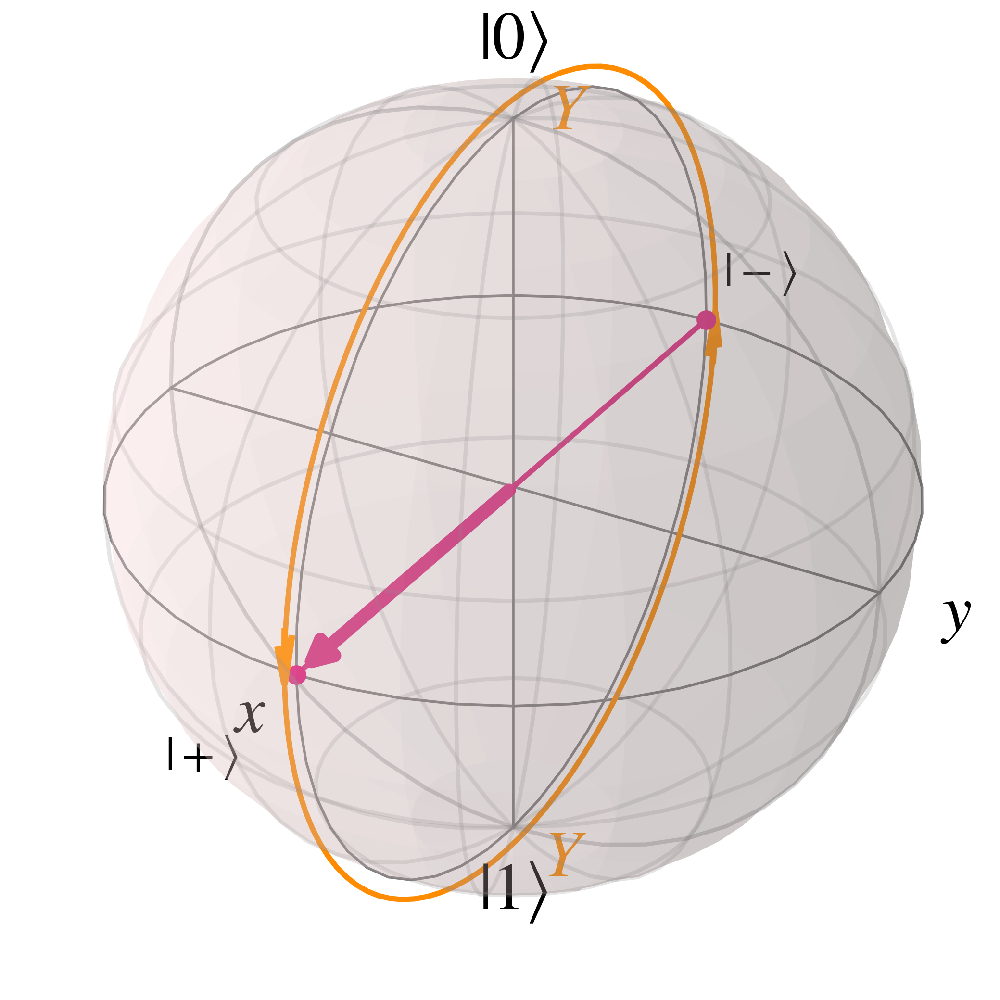

In [86]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# 1. Start with a sphere showing the initial |+> state on the X-axis
fig_y_gate = plot_bloch_vector([1, np.pi/2, 0], coord_type='spherical')
ax = fig_y_gate.axes[0]

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# 2. Draw the |+> and |-> state vectors
vector_color = '#dc267f'

states = {
    r'$|+\rangle$': (1, 0, 0),
    r'$|-\rangle$': (-1, 0, 0)
}

for label, (qx, qy, qz) in states.items():
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.plot([0, mx], [0, my], [0, mz], color=vector_color, linewidth=2)
    ax.scatter([mx], [my], [mz], color=vector_color, s=40)

# 3. Add text labels for the X-axis poles and the Z-axis crossing points
labels = {
    r'$|+\rangle$': (1.4, 0, 0),
    r'$|-\rangle$': (-1.3, 0, 0),
}

font_style = {'fontsize': 18, 'verticalalignment': 'center', 'horizontalalignment': 'center'}
for text, (qx, qy, qz) in labels.items():
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.text(mx, my, mz, text, **font_style)

# =========================================================================
# --- DRAWING THE Y-GATE ROTATION (X-Z PLANE) ---
# =========================================================================
ring_color = 'darkorange'
radius = 1.05

def draw_xz_arc_with_arrow(start_gamma, end_gamma):
    # 1. Draw solid arc segment in the X-Z plane (rotating around Y)
    gamma_angles = np.linspace(start_gamma, end_gamma, 50)
    
    # Parametric equation for rotation around Y-axis starting from +X
    q_arc_x = radius * np.cos(gamma_angles)
    q_arc_y = np.zeros(50)
    q_arc_z = -radius * np.sin(gamma_angles) 
    
    m_arc_x, m_arc_y, m_arc_z = q_to_m(q_arc_x, q_arc_y, q_arc_z)
    
    ax.plot(m_arc_x, m_arc_y, m_arc_z, color=ring_color, linewidth=2)

    # 2. Draw 3D arrowhead at the end point
    qx_head = radius * np.cos(end_gamma)
    qy_head = 0
    qz_head = -radius * np.sin(end_gamma)
    mx_head, my_head, mz_head = q_to_m(qx_head, qy_head, qz_head)
    
    gamma_prev = end_gamma - 0.1
    qx_prev = radius * np.cos(gamma_prev)
    qy_prev = 0
    qz_prev = -radius * np.sin(gamma_prev)
    mx_prev, my_prev, mz_prev = q_to_m(qx_prev, qy_prev, qz_prev)
    
    v_dir = (mx_head - mx_prev, my_head - my_prev, mz_head - mz_prev)
    v_dir_norm = v_dir / np.linalg.norm(v_dir)
    
    # 3D Quiver arrowhead (safe from the previous bug!)
    ax.quiver(mx_head, my_head, mz_head, v_dir_norm[0], v_dir_norm[1], v_dir_norm[2], 
              color=ring_color, length=0.15, normalize=False, 
              arrow_length_ratio=0.8, pivot='tip', linewidth=2.5)

# --- Define the two Y-gate rotation semicircles (180 degrees each) ---
# First Y Gate: |+> down to |-> (gamma from 0 to pi)
draw_xz_arc_with_arrow(0, np.pi)

# Second Y Gate: |-> back up to |+> (gamma from pi to 2pi)
draw_xz_arc_with_arrow(np.pi, 2*np.pi)
# =========================================================================

# 5. Add "Y" labels at the 90-degree midpoints
y_label_angles = [np.pi/2, 3*np.pi/2]
for angle in y_label_angles:
    qx = 1.05 * np.cos(angle)
    qy = 0.15
    qz = -1.05 * np.sin(angle)
    mx, my, mz = q_to_m(qx, qy, qz)
    
    ax.text(mx, my, mz, r'$Y$', color=ring_color, fontsize=25, fontweight='bold',
            ha='center', va='center')

# Save cleanly to avoid cutoffs
plt.savefig(figure_directory+'y_gate_rotations.png', bbox_inches='tight', pad_inches=0.1)

# Display once and clear memory
plt.show()

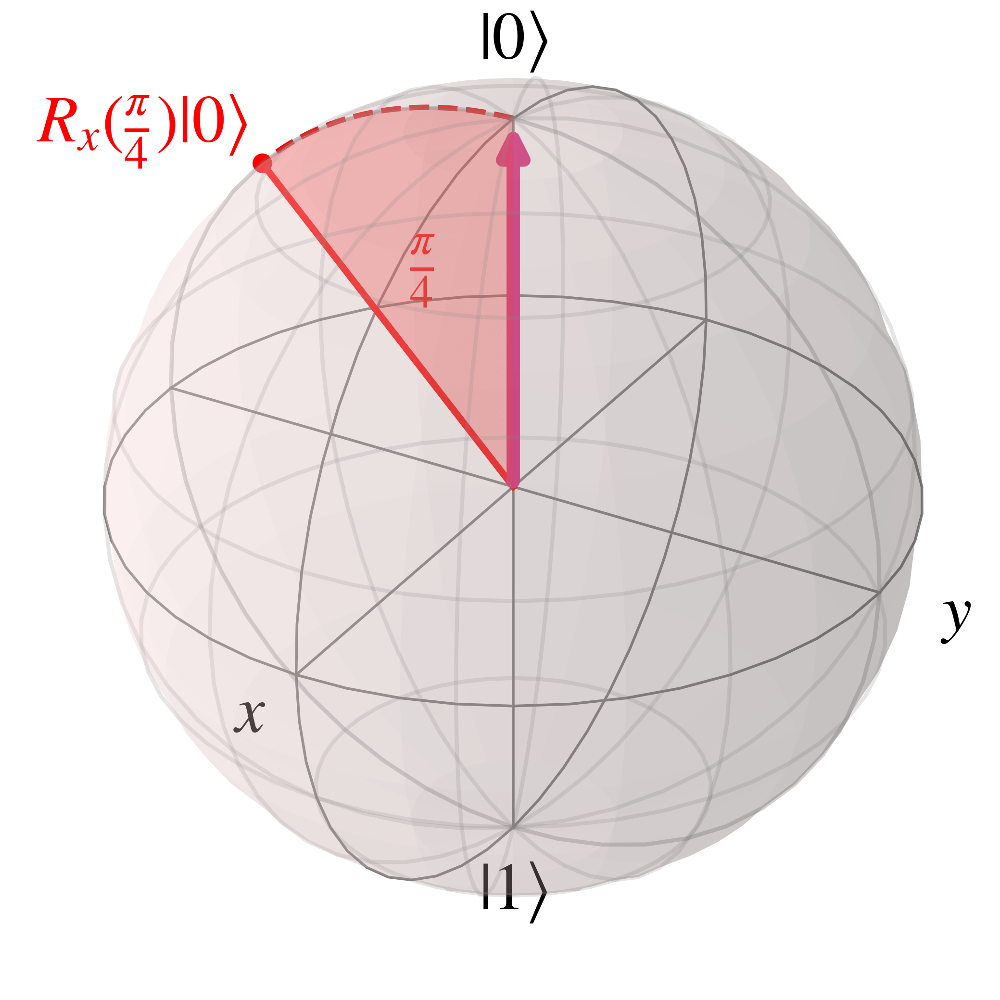

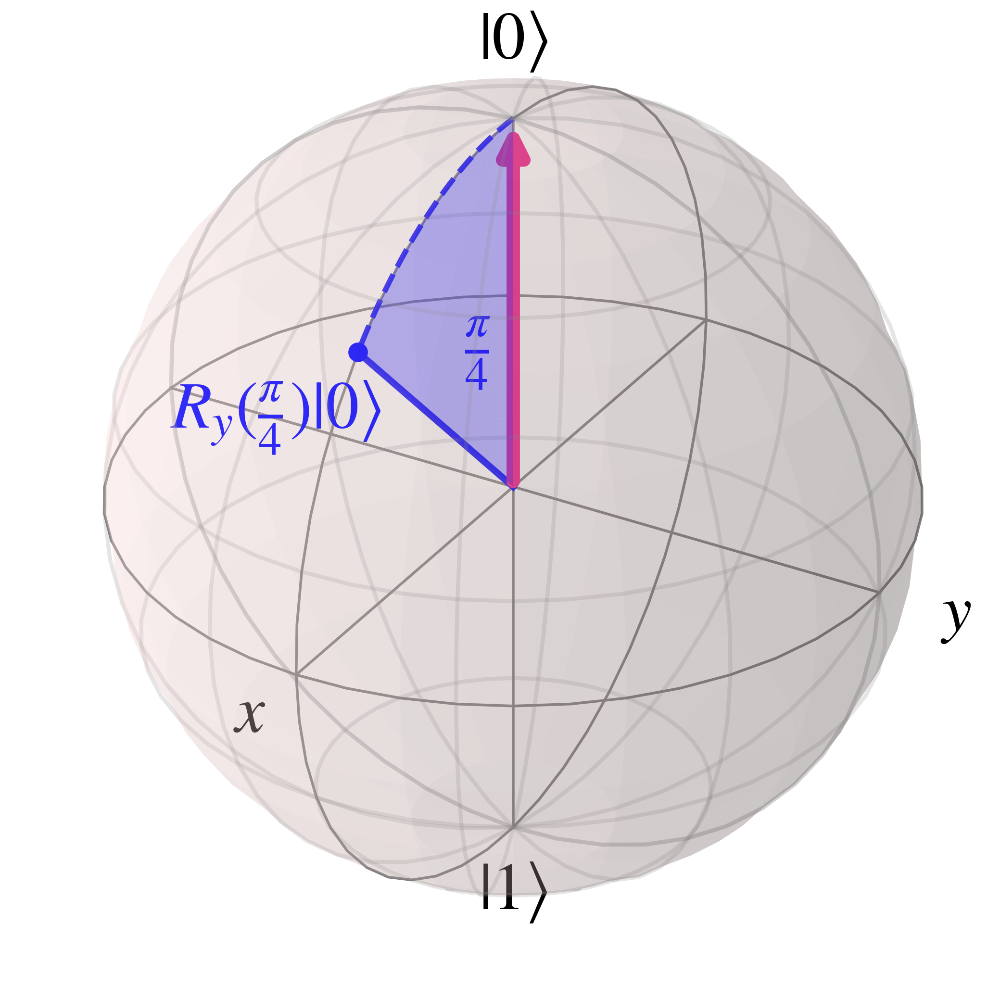

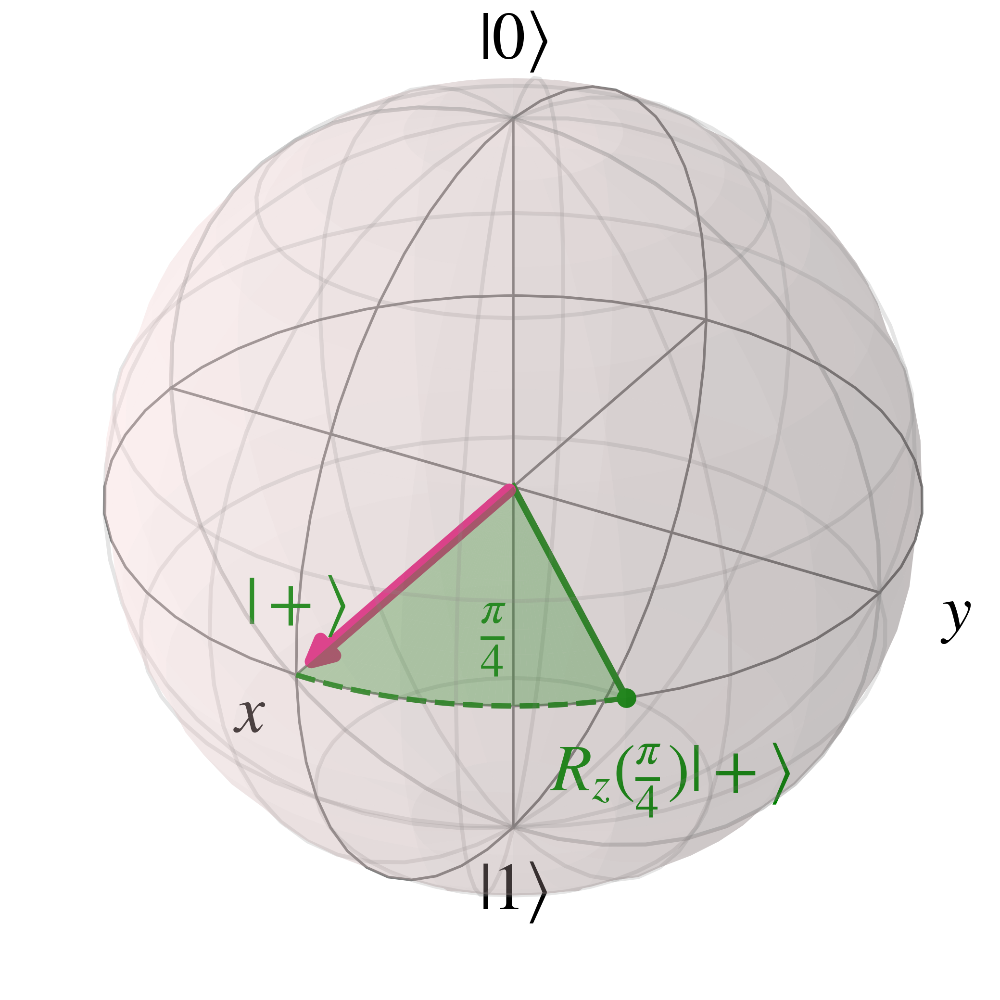

In [17]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# Rotation angle
gamma = np.pi / 4 

# Vector drawing helper function
def draw_vector(ax, qx, qy, qz, color, label='', label_offset=(0,0,0)):
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.plot([0, mx], [0, my], [0, mz], color=color, linewidth=2.5)
    ax.scatter([mx], [my], [mz], color=color, s=40)
    if label:
        lx, ly, lz = q_to_m(qx + label_offset[0], qy + label_offset[1], qz + label_offset[2])
        ax.text(lx, ly, lz, label, color=color, fontsize=25, ha='center', va='center')

# ==========================================
# --- FIGURE 1: Rx(pi/4) on |0> ------------
# ==========================================
# Pass [0,0,1] so Qiskit natively draws the initial |0> state
fig_rx = plot_bloch_vector([0, 0, 1])#, title=r'$R_x(\pi/4)$ applied to $|0\rangle$')
ax_rx = fig_rx.axes[0]

# Label the initial |0> state (Qiskit draws it in pink: #dc267f)
# lx, ly, lz = q_to_m(0, 0, 1.15)
#ax_rx.text(lx, ly, lz, r'$|0\rangle$', color='#dc267f', fontsize=14, ha='center', va='center')

# Final State Rx|0> (Red)
# Rotation around X drops the vector towards the -Y axis
rx_qx, rx_qy, rx_qz = 0, -np.sin(gamma), np.cos(gamma)
draw_vector(ax_rx, rx_qx, rx_qy, rx_qz, 'red', r'$R_x(\frac{\pi}{4})|0\rangle$', label_offset=(0, -0.35, 0))

# The Shaded Arc (Red)
angles = np.linspace(0, gamma, 50)
m_arc_x, m_arc_y, m_arc_z = q_to_m(np.zeros(50), -np.sin(angles), np.cos(angles))
ax_rx.plot(m_arc_x, m_arc_y, m_arc_z, color='red', linestyle='dashed', linewidth=2)

r_val = np.linspace(0, 1, 10)
T, R = np.meshgrid(angles, r_val)
m_surf_x, m_surf_y, m_surf_z = q_to_m(np.zeros_like(T), -R * np.sin(T), R * np.cos(T))
ax_rx.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='red', alpha=0.3, shade=False)

# Annotation
t_x, t_y, t_z = q_to_m(0, -0.6 * np.sin(gamma/2), 0.6 * np.cos(gamma/2))
ax_rx.text(t_x, t_y - 0.1, t_z, r'$\frac{\pi}{4}$', color='red')

fig_rx.savefig("rx_pi4_rotation.png", bbox_inches="tight")


# ==========================================
# --- FIGURE 2: Ry(pi/4) on |0> ------------
# ==========================================
fig_ry = plot_bloch_vector([0, 0, 1])#, title=r'$R_y(\pi/4)$ applied to $|0\rangle$')
ax_ry = fig_ry.axes[0]

# Label the initial |0> state
# lx, ly, lz = q_to_m(0, 0, 1.15)
#ax_ry.text(lx, ly, lz, r'$|0\rangle$', color='#dc267f', fontsize=14, ha='center', va='center')

# Final State Ry|0> (Blue)
# Rotation around Y drops the vector towards the +X axis
ry_qx, ry_qy, ry_qz = np.sin(gamma), 0, np.cos(gamma)
draw_vector(ax_ry, ry_qx, ry_qy, ry_qz, 'blue', r'$R_y(\frac{\pi}{4})|0\rangle$', label_offset=(0.35, 0, 0))

# The Shaded Arc (Blue)
m_arc_x, m_arc_y, m_arc_z = q_to_m(np.sin(angles), np.zeros(50), np.cos(angles))
ax_ry.plot(m_arc_x, m_arc_y, m_arc_z, color='blue', linestyle='dashed', linewidth=2)

m_surf_x, m_surf_y, m_surf_z = q_to_m(R * np.sin(T), np.zeros_like(T), R * np.cos(T))
ax_ry.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='blue', alpha=0.3, shade=False)

# Annotation
t_x, t_y, t_z = q_to_m(0.6 * np.sin(gamma/2), 0, 0.6 * np.cos(gamma/2))
ax_ry.text(t_x, t_y, t_z - 0.1, r'$\frac{\pi}{4}$', color='blue')

fig_ry.savefig("ry_pi4_rotation.png", bbox_inches="tight")


# ==========================================
# --- FIGURE 3: Rz(pi/4) on |+> ------------
# ==========================================
fig_rz = plot_bloch_vector([1, 0, 0])#, title=r'$R_z(\pi/4)$ applied to $|+\rangle$')
ax_rz = fig_rz.axes[0]

# Final State Rz|+> (Green)
# FIX: Positive rotation around Z moves from X towards Y
rz_qx, rz_qy, rz_qz = np.cos(gamma), np.sin(gamma), 0
draw_vector(ax_rz, rz_qx, rz_qy, rz_qz, 'green', r'$R_z(\frac{\pi}{4})|+\rangle$', label_offset=(0.25, 0.25, 0))

# The Shaded Arc (Green)
m_arc_x, m_arc_y, m_arc_z = q_to_m(np.cos(angles), np.sin(angles), np.zeros(50))
ax_rz.plot(m_arc_x, m_arc_y, m_arc_z, color='green', linestyle='dashed', linewidth=2)

m_surf_x, m_surf_y, m_surf_z = q_to_m(R * np.cos(T), R * np.sin(T), np.zeros_like(T))
ax_rz.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='green', alpha=0.3, shade=False)

# Annotation
lx, ly, lz = q_to_m(1.0, 0, 0.1)
ax_rz.text(lx, ly, lz, r'$|+\rangle$', color='green', ha='center', va='bottom')

t_x, t_y, t_z = q_to_m(0.6 * np.cos(gamma/2), 0.6 * np.sin(gamma/2), 0)
ax_rz.text(t_x, t_y, t_z - 0.1, r'$\frac{\pi}{4}$', color='green')

fig_rz.savefig("rz_pi4_rotation.png", bbox_inches="tight")

plt.show()

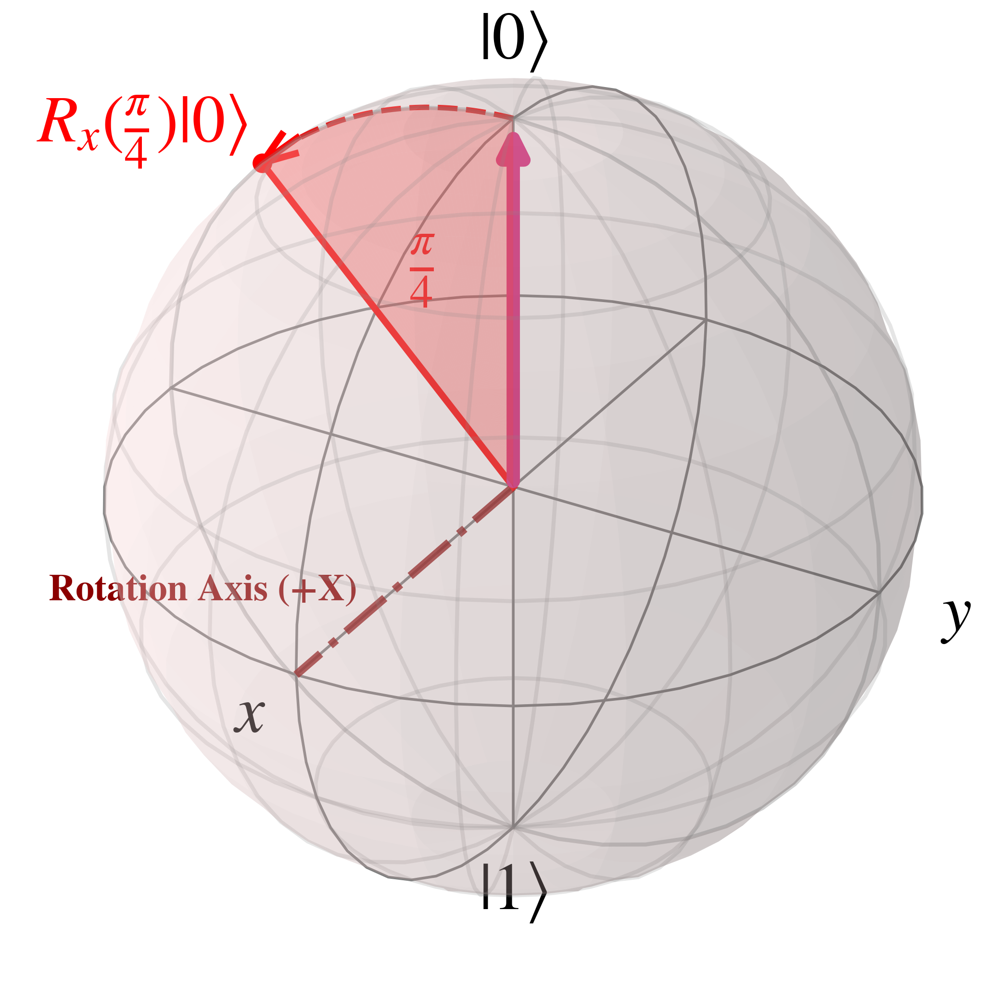

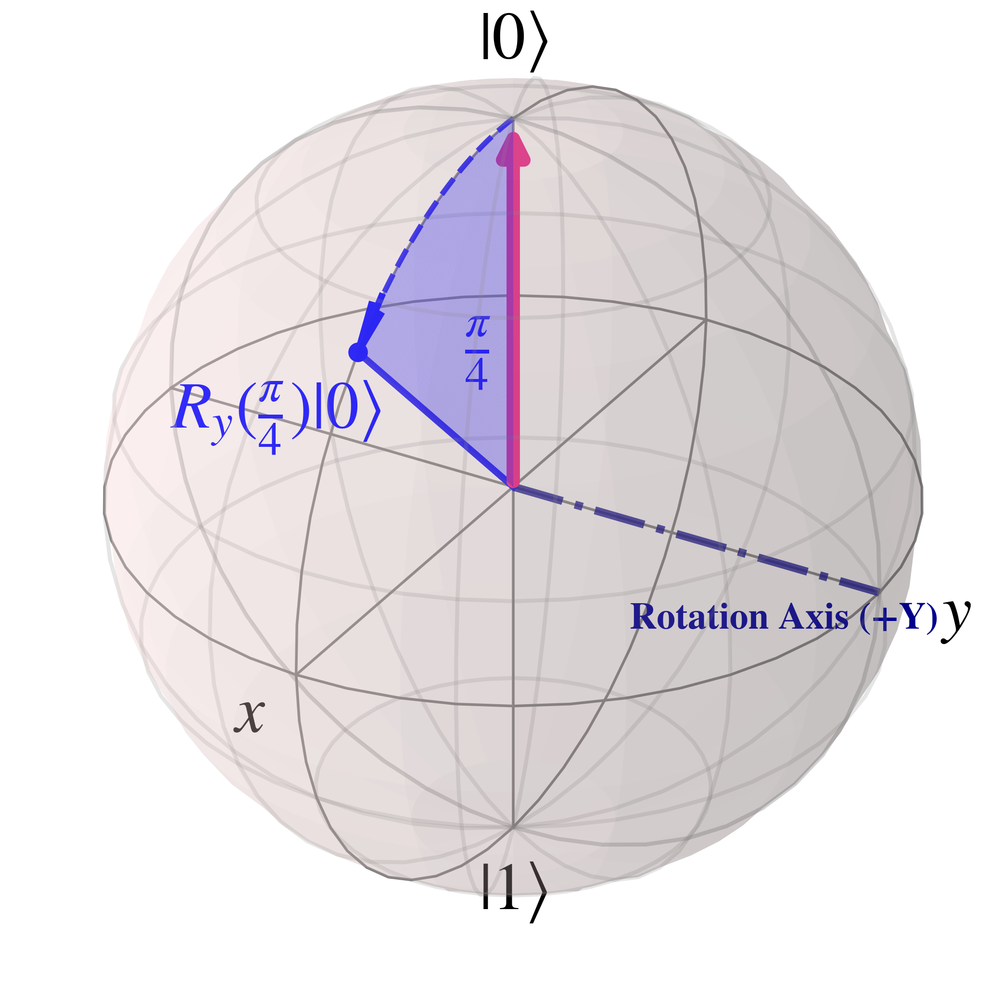

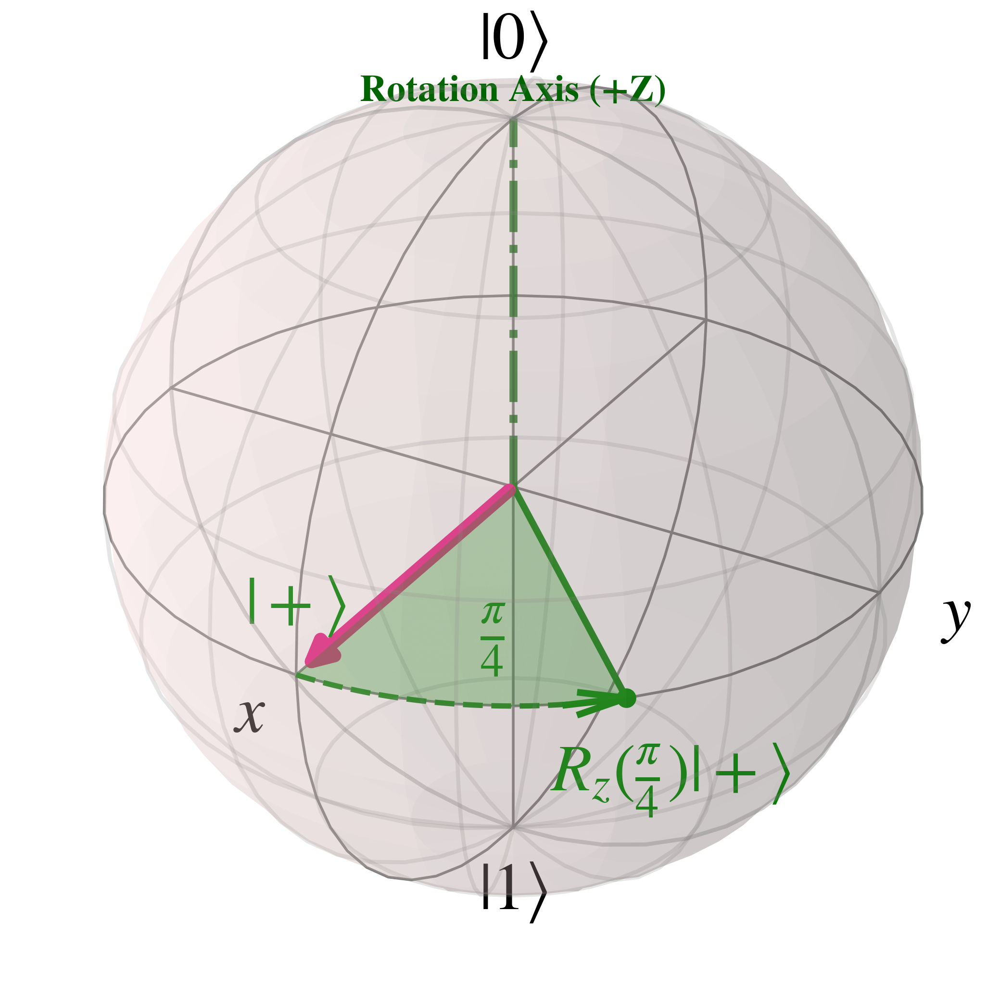

In [34]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# Rotation angle
gamma = np.pi / 4 

# Vector drawing helper function
def draw_vector(ax, qx, qy, qz, color, label='', label_offset=(0,0,0)):
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.plot([0, mx], [0, my], [0, mz], color=color, linewidth=2.5)
    ax.scatter([mx], [my], [mz], color=color, s=40)
    if label:
        lx, ly, lz = q_to_m(qx + label_offset[0], qy + label_offset[1], qz + label_offset[2])
        ax.text(lx, ly, lz, label, color=color, fontsize=25, ha='center', va='center')

# --- NEW: Helper to draw the rotation axis prominently ---
def highlight_axis(ax, qx, qy, qz, color, label, label_offset=(0,0,0)):
    mx, my, mz = q_to_m(qx, qy, qz)
    # Draw a thick dash-dot line originating from center
    ax.plot([0, mx], [0, my], [0, mz], color=color, linewidth=3, linestyle='-.', alpha=0.8)
    # Add the text label slightly past the end of the line
    lx, ly, lz = q_to_m(qx+label_offset[0], qy+label_offset[1], qz+label_offset[2])
    ax.text(lx, ly, lz, label, color=color, fontsize=14, fontweight='bold', ha='center', va='center')

# --- NEW: Helper to draw a 3D arrowhead at the end of the arc ---
def draw_arc_arrow(ax, qx_end, qy_end, qz_end, qx_prev, qy_prev, qz_prev, color):
    mx_head, my_head, mz_head = q_to_m(qx_end, qy_end, qz_end)
    mx_prev, my_prev, mz_prev = q_to_m(qx_prev, qy_prev, qz_prev)
    
    # Calculate direction vector for the arrow
    v_dir = (mx_head - mx_prev, my_head - my_prev, mz_head - mz_prev)
    v_dir_norm = v_dir / np.linalg.norm(v_dir)
    
    # 3D Quiver arrowhead
    ax.quiver(mx_head, my_head, mz_head, v_dir_norm[0], v_dir_norm[1], v_dir_norm[2], 
              color=color, length=0.15, normalize=False, 
              arrow_length_ratio=0.8, pivot='tip', linewidth=2.5)


# ==========================================
# --- FIGURE 1: Rx(pi/4) on |0> ------------
# ==========================================
fig_rx = plot_bloch_vector([0, 0, 1])
ax_rx = fig_rx.axes[0]

# Highlight the +X axis
highlight_axis(ax_rx, 1, 0, 0, 'darkred', 'Rotation Axis (+X)', label_offset=(0, -0.25, 0.15))

# Final State Rx|0> (Red)
rx_qx, rx_qy, rx_qz = 0, -np.sin(gamma), np.cos(gamma)
draw_vector(ax_rx, rx_qx, rx_qy, rx_qz, 'red', r'$R_x(\frac{\pi}{4})|0\rangle$', label_offset=(0, -0.35, 0))

# The Shaded Arc & Arrow (Red)
angles = np.linspace(0, gamma, 50)
m_arc_x, m_arc_y, m_arc_z = q_to_m(np.zeros(50), -np.sin(angles), np.cos(angles))
ax_rx.plot(m_arc_x, m_arc_y, m_arc_z, color='red', linestyle='dashed', linewidth=2)

draw_arc_arrow(ax_rx, 0, -np.sin(gamma), np.cos(gamma), 0, -np.sin(gamma-0.1), np.cos(gamma-0.1), 'red')

r_val = np.linspace(0, 1, 10)
T, R = np.meshgrid(angles, r_val)
m_surf_x, m_surf_y, m_surf_z = q_to_m(np.zeros_like(T), -R * np.sin(T), R * np.cos(T))
ax_rx.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='red', alpha=0.3, shade=False)

# Annotation
t_x, t_y, t_z = q_to_m(0, -0.6 * np.sin(gamma/2), 0.6 * np.cos(gamma/2))
ax_rx.text(t_x, t_y - 0.1, t_z, r'$\frac{\pi}{4}$', color='red')

fig_rx.savefig(figure_directory+"rx_pi4_rotation.png", bbox_inches="tight")


# ==========================================
# --- FIGURE 2: Ry(pi/4) on |0> ------------
# ==========================================
fig_ry = plot_bloch_vector([0, 0, 1])
ax_ry = fig_ry.axes[0]

# Highlight the +Y axis
highlight_axis(ax_ry, 0, 1, 0, 'darkblue', 'Rotation Axis (+Y)', label_offset=(0, -0.25, -0.15))

# Final State Ry|0> (Blue)
ry_qx, ry_qy, ry_qz = np.sin(gamma), 0, np.cos(gamma)
draw_vector(ax_ry, ry_qx, ry_qy, ry_qz, 'blue', r'$R_y(\frac{\pi}{4})|0\rangle$', label_offset=(0.35, 0, 0))

# The Shaded Arc & Arrow (Blue)
m_arc_x, m_arc_y, m_arc_z = q_to_m(np.sin(angles), np.zeros(50), np.cos(angles))
ax_ry.plot(m_arc_x, m_arc_y, m_arc_z, color='blue', linestyle='dashed', linewidth=2)

draw_arc_arrow(ax_ry, np.sin(gamma), 0, np.cos(gamma), np.sin(gamma-0.1), 0, np.cos(gamma-0.1), 'blue')

m_surf_x, m_surf_y, m_surf_z = q_to_m(R * np.sin(T), np.zeros_like(T), R * np.cos(T))
ax_ry.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='blue', alpha=0.3, shade=False)

# Annotation
t_x, t_y, t_z = q_to_m(0.6 * np.sin(gamma/2), 0, 0.6 * np.cos(gamma/2))
ax_ry.text(t_x, t_y, t_z - 0.1, r'$\frac{\pi}{4}$', color='blue')

fig_ry.savefig(figure_directory+"ry_pi4_rotation.png", bbox_inches="tight")


# ==========================================
# --- FIGURE 3: Rz(pi/4) on |+> ------------
# ==========================================
fig_rz = plot_bloch_vector([1, 0, 0])
ax_rz = fig_rz.axes[0]

# Highlight the +Z axis
highlight_axis(ax_rz, 0, 0, 1, 'darkgreen', 'Rotation Axis (+Z)', label_offset=(0,0,0.07))

# Final State Rz|+> (Green)
rz_qx, rz_qy, rz_qz = np.cos(gamma), np.sin(gamma), 0
draw_vector(ax_rz, rz_qx, rz_qy, rz_qz, 'green', r'$R_z(\frac{\pi}{4})|+\rangle$', label_offset=(0.25, 0.25, 0))

# The Shaded Arc & Arrow (Green)
m_arc_x, m_arc_y, m_arc_z = q_to_m(np.cos(angles), np.sin(angles), np.zeros(50))
ax_rz.plot(m_arc_x, m_arc_y, m_arc_z, color='green', linestyle='dashed', linewidth=2)

draw_arc_arrow(ax_rz, np.cos(gamma), np.sin(gamma), 0, np.cos(gamma-0.1), np.sin(gamma-0.1), 0, 'green')

m_surf_x, m_surf_y, m_surf_z = q_to_m(R * np.cos(T), R * np.sin(T), np.zeros_like(T))
ax_rz.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='green', alpha=0.3, shade=False)

# Annotation
lx, ly, lz = q_to_m(1.0, 0, 0.1)
ax_rz.text(lx, ly, lz, r'$|+\rangle$', color='green', ha='center', va='bottom')

t_x, t_y, t_z = q_to_m(0.6 * np.cos(gamma/2), 0.6 * np.sin(gamma/2), 0)
ax_rz.text(t_x, t_y, t_z - 0.1, r'$\frac{\pi}{4}$', color='green')

fig_rz.savefig(figure_directory+"rz_pi4_rotation.png", bbox_inches="tight")

#plt.show()

## Multi-qubit gates

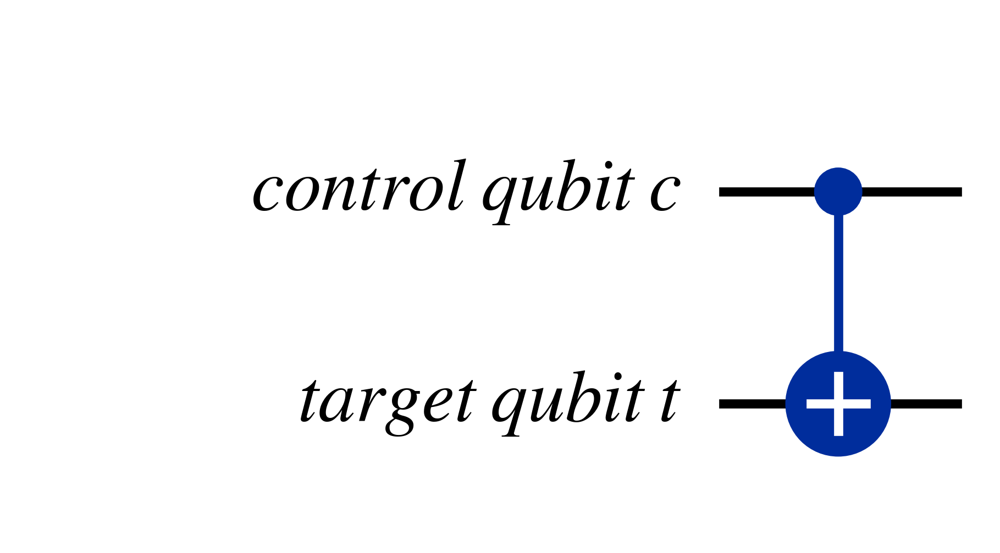

In [19]:
label_c = "control qubit c"
label_t = "target qubit t"

qr_c = QuantumRegister(1, name=label_c)
qr_t = QuantumRegister(1, name=label_t)

qc_cnot = QuantumCircuit(qr_c, qr_t)
qc_cnot.cx(qr_c, qr_t)

fig_cnot = qc_cnot.draw(output='mpl', scale =1.5, initial_state=False)
fig_cnot.savefig(figure_directory+'cnot_gate_demonstration.png', bbox_inches='tight')

In [12]:
label_c = "control qubit c"
label_t = "target qubit t"

qr_c = QuantumRegister(1, name=label_c)
qr_t = QuantumRegister(1, name=label_t)

qc_control_u = QuantumCircuit(qr_c, qr_t)

control_u_gate = UGate().control(1)


qc_control_u.append(control_u_gate, qr_t)

fig_control_u  = qc_control_u.draw(output='mpl', scale =1.5, initial_state=False)
#fig_cnot.savefig(figure_directory+'cnot_gate_demonstration.png', bbox_inches='tight')

NameError: name 'UGate' is not defined

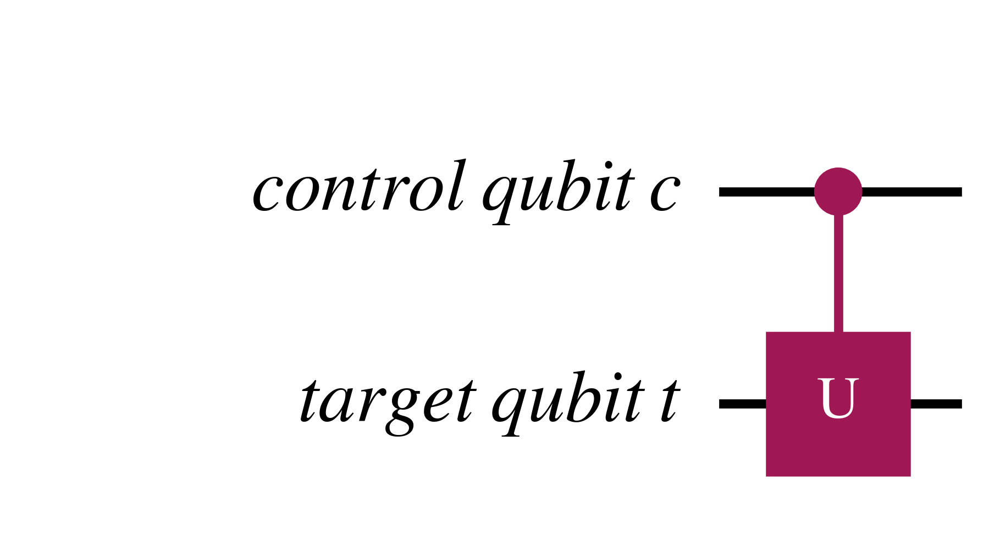

In [15]:
# Note: the following figure made use of AI assistance.

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Gate

label_c = "control qubit c"
label_t = "target qubit t"

qr_c = QuantumRegister(1, name=label_c)
qr_t = QuantumRegister(1, name=label_t)

qc_control_u = QuantumCircuit(qr_c, qr_t)

# 1. Create a generic custom gate named "U"
u_gate = Gate(name='U', num_qubits=1, params=[])

# 2. Add 1 control wire using annotated=True!
# This tells Qiskit "Don't try to compile the math, just tag it visually."
control_u_gate = u_gate.control(1, annotated=True)

# 3. Append the gate to the circuit using both wires
qc_control_u.append(control_u_gate, [qr_c, qr_t])

# Draw the circuit
fig_control_u = qc_control_u.draw(output='mpl', scale=1.5, initial_state=False)

# Save the figure
fig_control_u.savefig(figure_directory+'control_u_gate_demonstration.png', bbox_inches='tight')



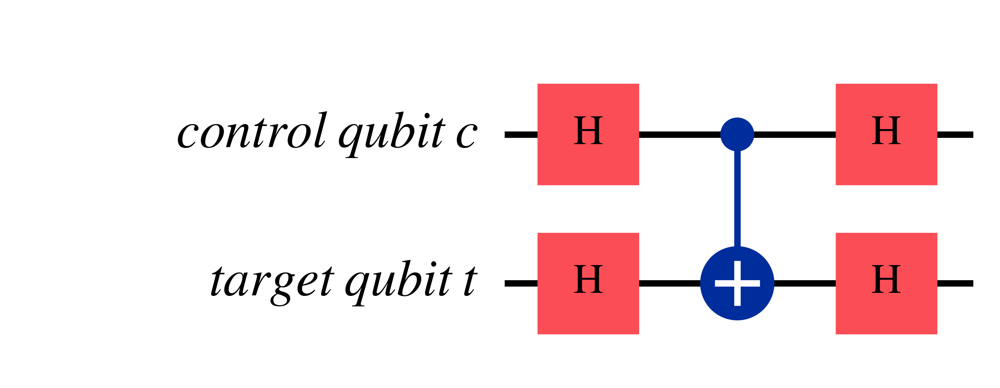

In [16]:
label_c = "control qubit c"
label_t = "target qubit t"

qr_c = QuantumRegister(1, name=label_c)
qr_t = QuantumRegister(1, name=label_t)

qc_cnot = QuantumCircuit(qr_c, qr_t)
qc_cnot.h(qr_c)
qc_cnot.h(qr_t)
qc_cnot.cx(qr_c, qr_t)
qc_cnot.h(qr_c)
qc_cnot.h(qr_t)

fig_cnot = qc_cnot.draw(output='mpl', scale =1.5, initial_state=False)
fig_cnot.savefig(figure_directory+'cnot_with_hadamard_transform_gate_demonstration.png', bbox_inches='tight')

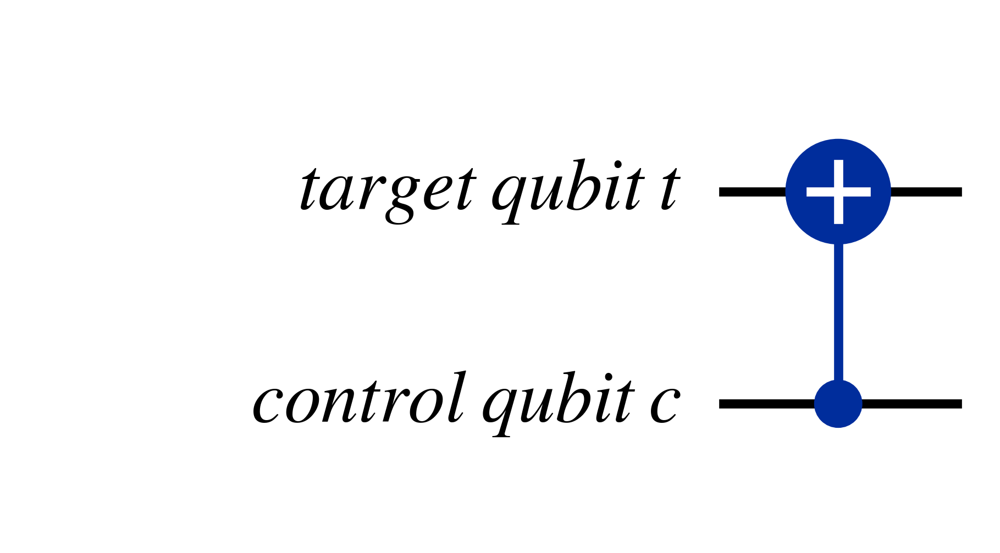

In [18]:
label_c = "control qubit c"
label_t = "target qubit t"

qr_c = QuantumRegister(1, name=label_c)
qr_t = QuantumRegister(1, name=label_t)

qc_cnot = QuantumCircuit(qr_t, qr_c)
qc_cnot.cx(qr_c, qr_t)

fig_cnot = qc_cnot.draw(output='mpl', scale =1.5, initial_state=False)
fig_cnot.savefig(figure_directory+'inverted_cnot_gate_demonstration.png', bbox_inches='tight')

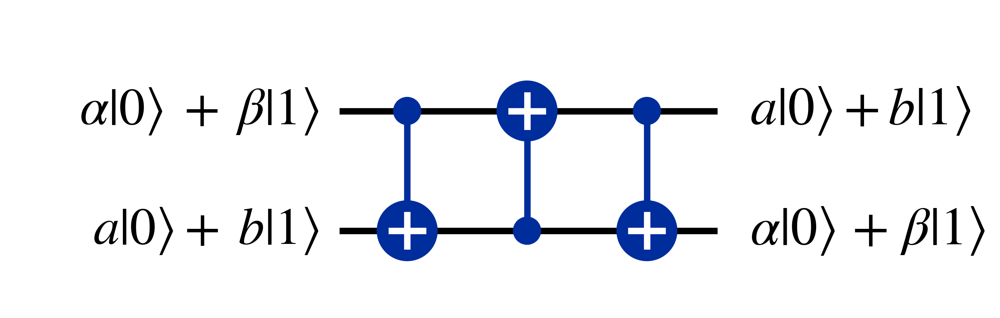

In [46]:

qr_1 = QuantumRegister(1, name='α|0⟩ + β|1⟩')
qr_2 = QuantumRegister(1, name='a|0⟩+ b|1⟩')

qc = QuantumCircuit(qr_1, qr_2)
qc.cx(qr_1, qr_2)
qc.cx(qr_2, qr_1)
qc.cx(qr_1, qr_2)

fig_qc = qc.draw(output='mpl', scale =1.5, initial_state=False)
ax = fig_qc.axes[0]
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 1.5)

font_style = {'fontsize': 25, 'verticalalignment': 'center'}
ax.text(x_max + 0.2, 0, r'$a|0\rangle + b|1\rangle$', **font_style)
ax.text(x_max + 0.2, -1, r"$\alpha|0\rangle$ + $\beta|1\rangle$", **font_style)

fig_qc.savefig(figure_directory+'three_cnot_swap_equivalent.png', bbox_inches='tight')

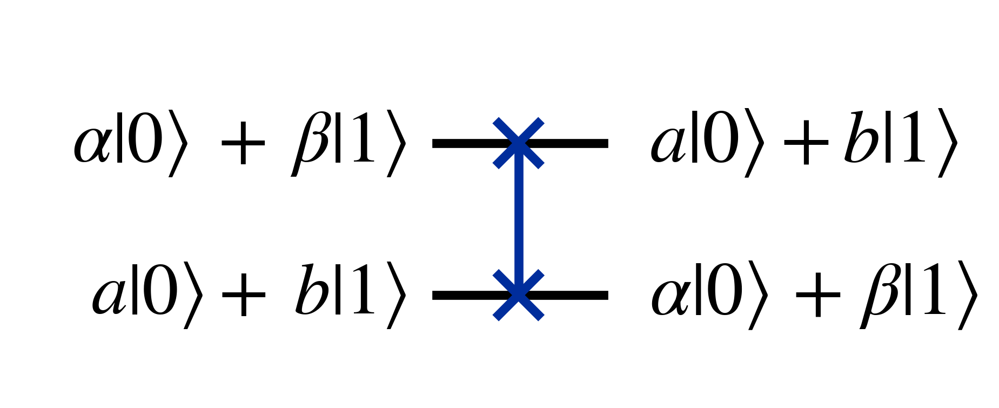

In [45]:
qr_1 = QuantumRegister(1, name='α|0⟩ + β|1⟩')
qr_2 = QuantumRegister(1, name='a|0⟩+ b|1⟩')

qc = QuantumCircuit(qr_1, qr_2)
qc.swap(qr_1, qr_2)


fig_qc = qc.draw(output='mpl', scale =1.5, initial_state=False)
ax = fig_qc.axes[0]
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 1.5)

font_style = {'fontsize': 25, 'verticalalignment': 'center'}
ax.text(x_max + 0.2, 0, r'$a|0\rangle + b|1\rangle$', **font_style)
ax.text(x_max + 0.2, -1, r"$\alpha|0\rangle$ + $\beta|1\rangle$", **font_style)

fig_qc.savefig(figure_directory+'swap_gate_demonstration.png', bbox_inches='tight')

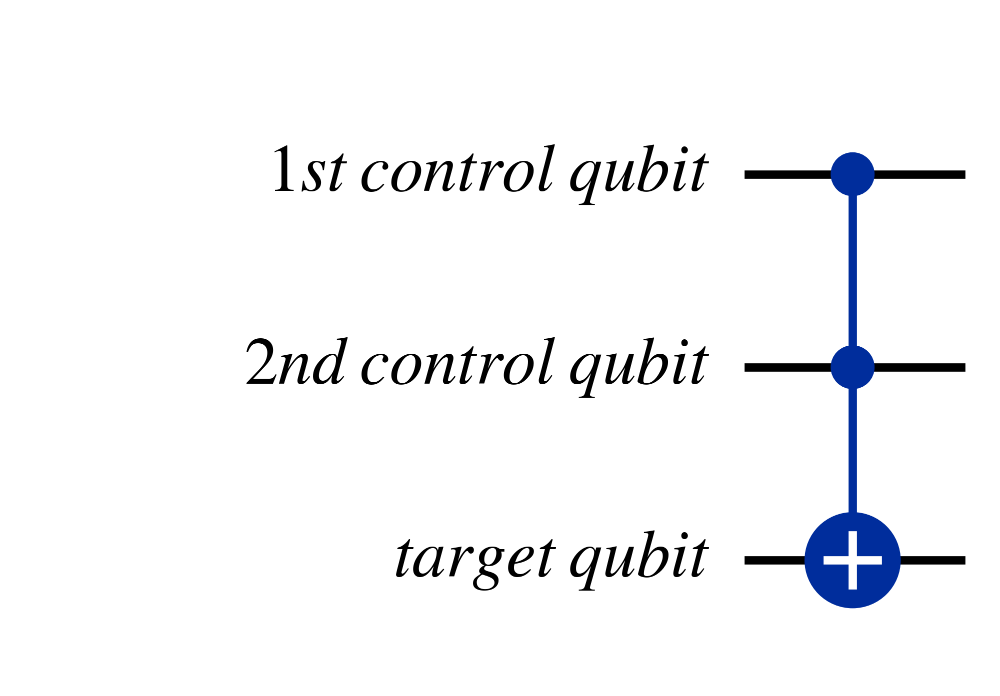

In [48]:
label_c1 = "1st control qubit"
label_c2 = "2nd control qubit"
label_t = "target qubit"

qr_c1 = QuantumRegister(1, name=label_c1)
qr_c2 = QuantumRegister(1, name=label_c2)
qr_t = QuantumRegister(1, name=label_t)

qc = QuantumCircuit(qr_c1, qr_c2, qr_t)
qc.ccx(qr_c1, qr_c2, qr_t)


fig = qc.draw(output='mpl', scale =1.5, initial_state=False)
fig.savefig(figure_directory+'toffoli_gate_demonstration.png', bbox_inches='tight')

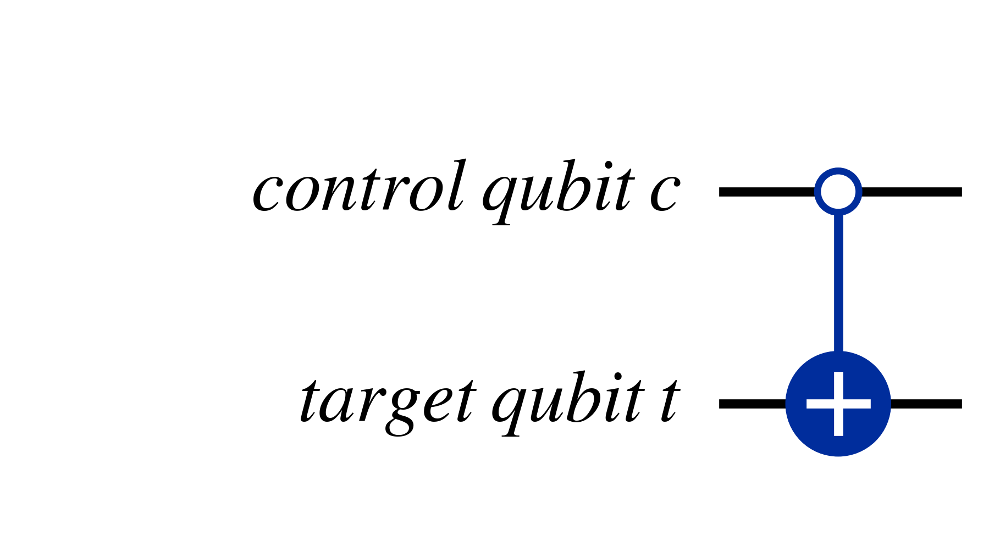

In [52]:
label_c = "control qubit c"
label_t = "target qubit t"

qr_c = QuantumRegister(1, name=label_c)
qr_t = QuantumRegister(1, name=label_t)

qc_cnot = QuantumCircuit(qr_c, qr_t)
qc_cnot.cx(qr_c, qr_t, ctrl_state=0)

fig_cnot = qc_cnot.draw(output='mpl', scale =1.5, initial_state=False)
fig_cnot.savefig(figure_directory+'zero_control_state_cnot_gate_demonstration.png', bbox_inches='tight')

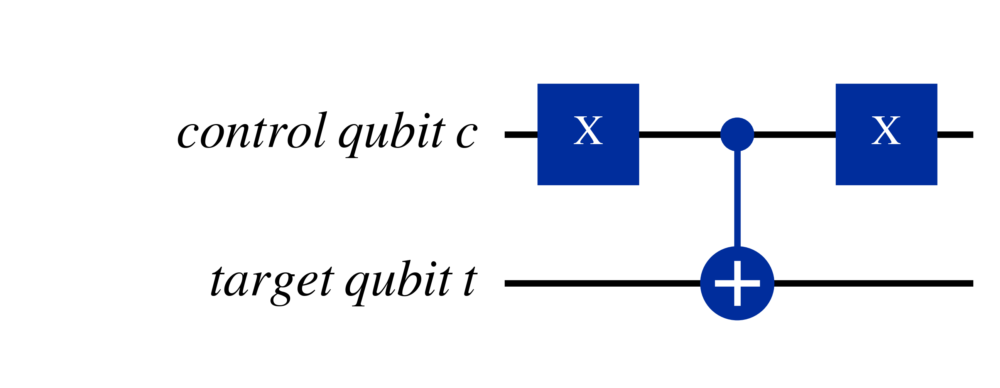

In [54]:
label_c = "control qubit c"
label_t = "target qubit t"

qr_c = QuantumRegister(1, name=label_c)
qr_t = QuantumRegister(1, name=label_t)

qc_cnot = QuantumCircuit(qr_c, qr_t)
qc_cnot.x(qr_c)
qc_cnot.cx(qr_c, qr_t)
qc_cnot.x(qr_c)

fig_cnot = qc_cnot.draw(output='mpl', scale =1.5, initial_state=False)
fig_cnot.savefig(figure_directory+'x_gates_and_cnot_zero_control_state_cnot_equivalent.png', bbox_inches='tight')